In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Carrega e prepara os dados
data = pd.read_csv("../../Data.csv")
data = data.drop(columns=["VD", "VE", "tempo"])
data.index = (np.arange(0, len(data), 1).astype(float) * 0.07).round(5)

data = data.rename(columns={
    "Setpoint VD": "Wd",
    "Setpoint VE": "We",
    "Theta": "theta(Wd,We)",
    "X": "x(Wd,We)",
    "Y": "y(Wd,We)",
})

In [2]:
import seaborn as sns
from sklearn.preprocessing import StandardScaler

PREDICTORS = ["Wd", "We"]
TARGET = ["theta(Wd,We)"]

def PlotTimeSeries(df, img_name="data.svg", PlotOut=True):    
    # Estilo Seaborn
    sns.set_theme(style="whitegrid")

    # Criando a figura
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plotando Wd e We como linhas
    for preds in PREDICTORS:
        sns.lineplot(x=df.index, y=df[preds], ax=ax1, marker="o", label=preds,  linewidth=2)

    if PlotOut:
        ax2 = ax1.twinx()
        for target in TARGET:
            sns.lineplot(x=df.index, y=df[target], ax=ax2, marker="o", label=target, linestyle="dashed", linewidth=2, color="red")
            ax2.set_ylabel("Posição Angular", fontsize=12, color="gray")

    # Ajustando os rótulos dos eixos
    ax1.set_xlabel("Tempo (s) - Período de amostragem (T=0.07 s)", fontsize=12)
    ax1.set_ylabel("Velocidade Angular", fontsize=12, color="black")

    # Adicionando legendas
    ax1.legend(loc="upper left")
    if PlotOut:
        ax2.legend(loc="upper right")

    # Título
    plt.title("Posição angular em função da velocidade nas rodas", fontsize=14)

    # Exibindo o gráfico
    plt.show()

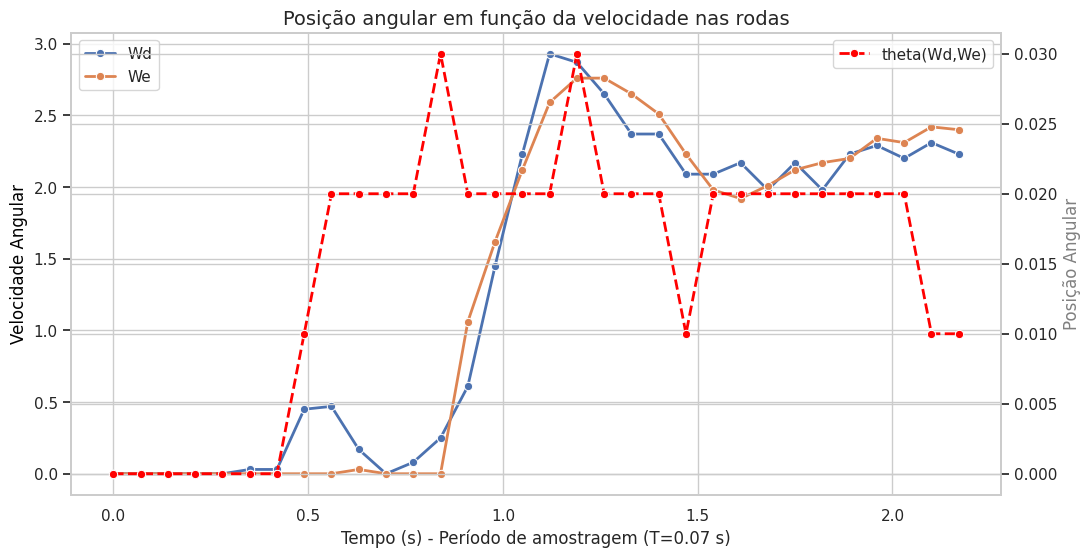

In [3]:
PlotTimeSeries(data.head(32))

In [4]:
PREDICTORS = ["Wd", "We"]
TARGET = "theta(Wd,We)"

def get_XY(data, time_steps, units, output_dim):
    total_samples = (len(data) - time_steps) // time_steps

    X = []
    Y = []
    
    for i in range(total_samples):
        start_idx = i * time_steps
        end_idx = start_idx + time_steps

        X_seq = data.iloc[start_idx:end_idx][PREDICTORS].values  # shape: (time_steps, features)
        Y_target = data.iloc[end_idx][TARGET]  # escalar

        X.append(X_seq)
        Y.append(Y_target)

    X = np.array(X)  # shape: (batch, time_steps, features)
    Y =  Y = np.array(Y).reshape(-1, 1).repeat(output_dim, axis=1)  # shape (batch, output_dim)
    h0 = np.full((X.shape[0], units), fill_value=Y[0]) # shape (batch, units)

    print(f"Shape X (batch, time_steps, features): {X.shape}")
    print(f"Shape Y (batch, output_dim): {Y.shape}")
    print(f"Shape h0 (batch, units): {h0.shape}")
    
    return X, Y, h0

In [5]:
def PlotOut(valuer):
    sns.set_theme(style="whitegrid")

    fig, axs = plt.subplots(3, 1, figsize=(12, 12), sharey=False)

    datasets = [
        ('Treinamento', valuer.train_samples_y, valuer.train_pred),
        ('Validação', valuer.val_samples_y, valuer.val_pred),
        ('Teste', valuer.test_samples_y, valuer.test_pred)
    ]

    times = [
        np.arange(len(valuer.train_samples_y)),
        np.arange(len(valuer.val_samples_y)),
        np.arange(len(valuer.test_samples_y))
    ]

    for i, (title, y_true, y_pred) in enumerate(datasets):
        # Garante que são vetores 1D
        y_true = np.ravel(y_true)
        y_pred = np.ravel(y_pred)

        sns.lineplot(x=times[i], y=y_true, ax=axs[i], marker="o", label="Amostras Reais", linewidth=2)
        sns.lineplot(x=times[i], y=y_pred, ax=axs[i], marker="o", label="Valores preditos", linewidth=2)

        axs[i].set_title(f'{title}')
        axs[i].set_xlabel('Tempo')
        axs[i].set_ylabel('Valor')
        axs[i].legend()
        axs[i].grid(True)

    plt.suptitle('Comparação temporal: Predição (curva) vs Amostras Reais (pontos)')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()  
    
    path = f"./content/models/{valuer.fileName}.png"
    fig.savefig(path)    

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error 
from keras import layers, models, regularizers, initializers, optimizers
from keras.callbacks import EarlyStopping
from itertools import product


class EvalRNN:
    
    def __init__(self, dataset, epochs, time_steps, act_h, act_o):
        self.epochs = epochs
        self.Dataset = dataset
        self.output_dim = np.size(TARGET)
        self.time_steps = time_steps
        self.act_h = act_h
        self.act_o = act_o
        self.better_metrics = {}


    def SplitData(self, units):
        self.units = units
                
        train_data, test_data = train_test_split(self.Dataset, test_size=0.25, shuffle=False)
        train_data, val_data = train_test_split(train_data, test_size=0.15, shuffle=False)
                
        self.train_samples_x, self.train_samples_y, self.h0_train = get_XY(train_data, self.time_steps, units, self.output_dim)       
        self.val_samples_x, self.val_samples_y, self.h0_val = get_XY(val_data, self.time_steps, units, self.output_dim)
        self.test_samples_x, self.test_samples_y, self.h0_test = get_XY(test_data, self.time_steps, units, self.output_dim)

        self.time_steps = self.train_samples_x.shape[1]
        self.features = self.train_samples_x.shape[2]
        
    def BuildModel(self, hidden_sizes, param_reg):
        initializer = initializers.RandomUniform(minval=-0.5,
                                                maxval=0.5,
                                                # seed=np.random.randint(1, 10000)
                                                )
        regularizer = regularizers.L2(param_reg)
        inputs = layers.Input((self.time_steps, self.features))
        initial_state = layers.Input((self.units,))

        # Primeira camada RNN com estado inicial
        rnn_layer = layers.SimpleRNN(
            hidden_sizes[0],
            activation=self.act_h,
            kernel_regularizer=regularizer,
            kernel_initializer=initializer,
            return_sequences=(len(hidden_sizes) > 1)  
        )(inputs, initial_state=initial_state)

        # Demais camadas RNN
        for size in hidden_sizes[1:-1]:
            rnn_layer = layers.SimpleRNN(
                size,
                activation=self.act_h,
                kernel_regularizer=regularizer,
                kernel_initializer=initializer,
                return_sequences=True 
            )(rnn_layer)

        # Última camada RNN
        if len(hidden_sizes) > 1:
            rnn_layer = layers.SimpleRNN(
                hidden_sizes[-1],
                activation=self.act_h,
                kernel_regularizer=regularizer,
                kernel_initializer=initializer,
                return_sequences=False  
            )(rnn_layer)
       
       # Output mlp layer
        output = layers.Dense(self.output_dim,
                            activation=self.act_o,
                            kernel_regularizer=regularizer,
                            kernel_initializer=initializer)(rnn_layer)
        
        model = models.Model([inputs] + [initial_state], output)
        return(model)
    
    def CompileModel(self, model, lr):
        model.compile(loss="mse", optimizer=optimizers.Adam(learning_rate=lr))
        early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

        model.fit(
            [self.train_samples_x, self.h0_train],
            self.train_samples_y,
            epochs=self.epochs,
            validation_data=([self.val_samples_x, self.h0_val], self.val_samples_y),
            callbacks=[early_stop],
            verbose=False,
            shuffle=False   
        )
    
    def ComputeMetrics(self, model):
        self.train_pred = np.squeeze(model.predict([self.train_samples_x, self.h0_train]))
        self.val_pred = np.squeeze(model.predict([self.val_samples_x, self.h0_val]))
        self.test_pred = np.squeeze(model.predict([self.test_samples_x, self.h0_test]))


        return ({
                    'r2_training': r2_score(self.train_samples_y, self.train_pred),
                    'mse_training': mean_squared_error(self.train_samples_y, self.train_pred),
                    'mape_training': mean_absolute_percentage_error(self.train_samples_y, self.train_pred),
                    'rmse_training': root_mean_squared_error(self.train_samples_y, self.train_pred),

                    'r2_test': r2_score(self.test_samples_y, self.test_pred),
                    'mse_test': mean_squared_error(self.test_samples_y, self.test_pred),
                    'mape_test': mean_absolute_percentage_error(self.test_samples_y, self.test_pred),
                    'rmse_test': root_mean_squared_error(self.test_samples_y, self.test_pred),
                    
                    'r2_val': r2_score(self.val_samples_y, self.val_pred),
                    'mse_val': mean_squared_error(self.val_samples_y, self.val_pred),
                    'mape_val': mean_absolute_percentage_error(self.val_samples_y, self.val_pred),
                    'rmse_val': root_mean_squared_error(self.val_samples_y, self.val_pred),
            })

    def SaveModelWeights(self, model):
        path = f"./content/models/{self.fileName}.weights.h5"
        open(path,'w').close()
        model.save_weights(path) 

    def LoopWeights(self, model, run_times, lr, boundarie, sort_by, idx):
        better_model = 0
        save = False

        for i in range(run_times):
            print (f"+++++++++++ [{idx}] | {i + 1} ++++++++++++++++++")
            self.CompileModel(model, lr)
            metrics = self.ComputeMetrics(model)
            
            if (metrics[sort_by] >= boundarie): # should be >= to acsending metrics
                self.fileName = f"model_{idx}_{better_model}"
                self.SaveModelWeights(model)
                self.better_metrics[self.fileName] = metrics
                better_model += 1
                save = True
                PlotOut(self)

        return(save)

    def Evaluate(self, hidden_sizes, regularizers, learning_rate, run_times, boundarie, sort_by):
        for count, (hidden_size, reg, lr) in enumerate(product(hidden_sizes, regularizers, learning_rate), start=1):
            header =  f"Hidden Size={hidden_size}, regularizer={reg}, learning_rate={lr}"
            print(f"Testando combinacao{count}: {header}")
            
            self.SplitData(units=hidden_size[0])        
            model = self.BuildModel(hidden_size, reg)
            
            if (self.LoopWeights(model, run_times, lr, boundarie, sort_by, f"{count}") == True):        
                self.DisplayBetterResults(header, sort_by, f"{count}")
                
        self.better_metrics = {}
  
                
    def DisplayBetterResults(self, header, sort_by, dataset=0):
        df = pd.DataFrame.from_dict(self.better_metrics, orient='index')
        df = df.sort_values([sort_by])
        display(df)
        path = f'./content/results/metrics_{dataset}'
        df.to_excel(f"{path}.xlsx", index=True)
        print(f"DataFrame salvo em {path}")
        with open(f"{path}.txt", 'w') as arquivo:
            arquivo.write(header)            
       

2025-05-13 00:29:26.362993: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-13 00:29:26.967012: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-13 00:29:27.143836: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747096167.608738  182017 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747096167.761222  182017 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1747096168.755816  182017 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [7]:
Valuer = EvalRNN(dataset = data,
                epochs = 5000,
                time_steps = 2,
                act_h = 'tanh',
                act_o = 'sigmoid',
                )        

Testando combinacao1: Hidden Size=[30], regularizer=0.2, learning_rate=0.01
Shape X (batch, time_steps, features): (682, 2, 2)
Shape Y (batch, output_dim): (682, 1)
Shape h0 (batch, units): (682, 30)
Shape X (batch, time_steps, features): (120, 2, 2)
Shape Y (batch, output_dim): (120, 1)
Shape h0 (batch, units): (120, 30)
Shape X (batch, time_steps, features): (267, 2, 2)
Shape Y (batch, output_dim): (267, 1)
Shape h0 (batch, units): (267, 30)
+++++++++++ [1] | 1 ++++++++++++++++++


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
+++++++++++ [1] | 2 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
+++++++++++ [1] | 3 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
+++++++++++ [1] | 4 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


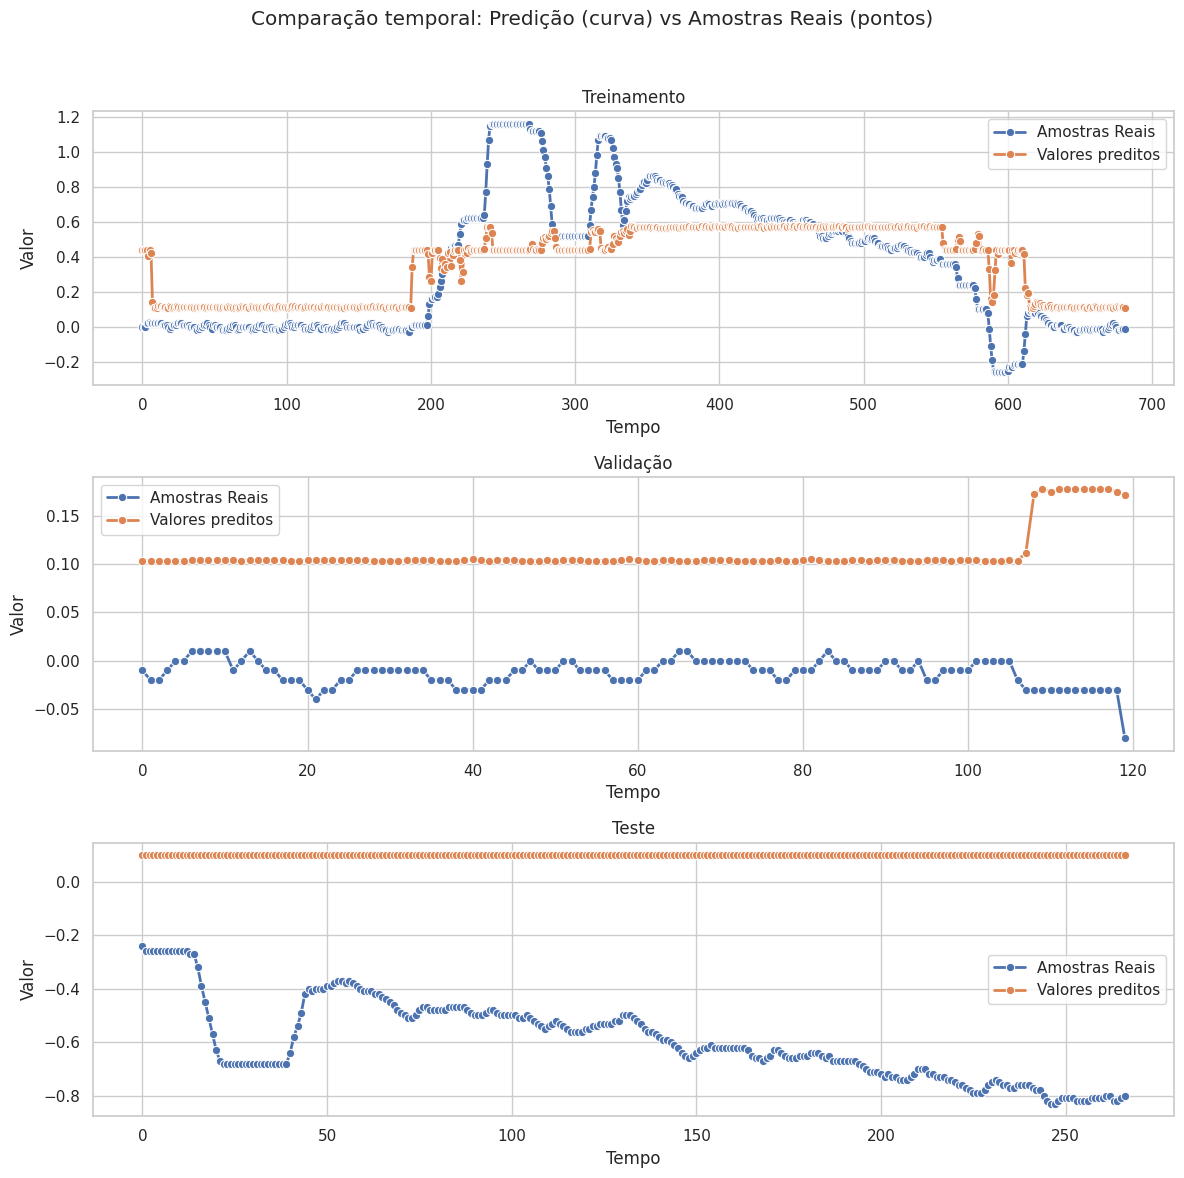

+++++++++++ [1] | 5 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


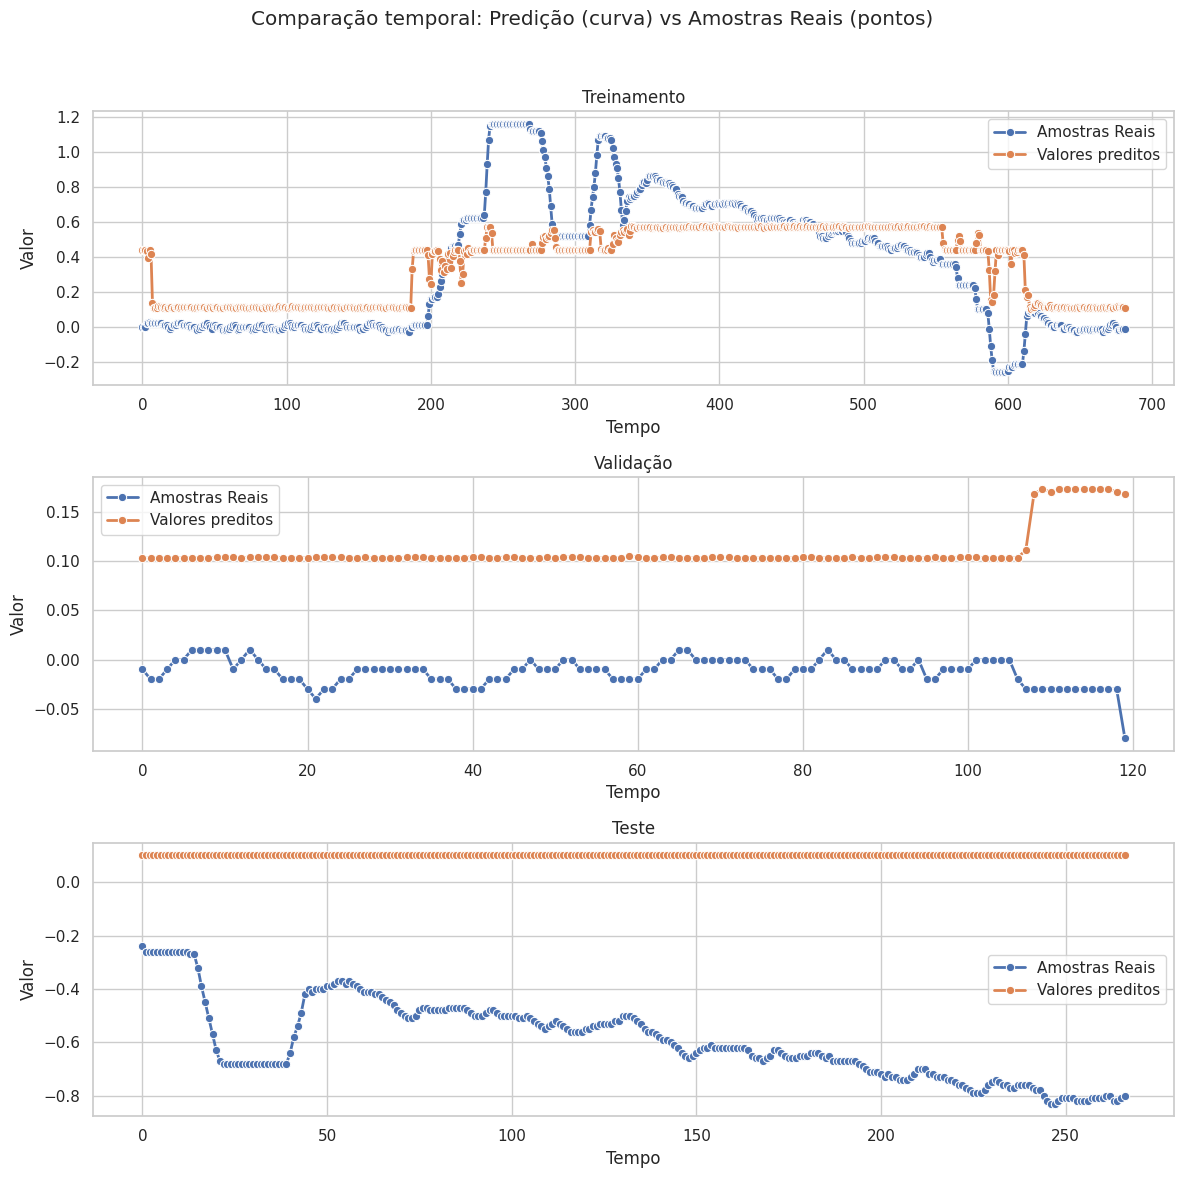

+++++++++++ [1] | 6 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


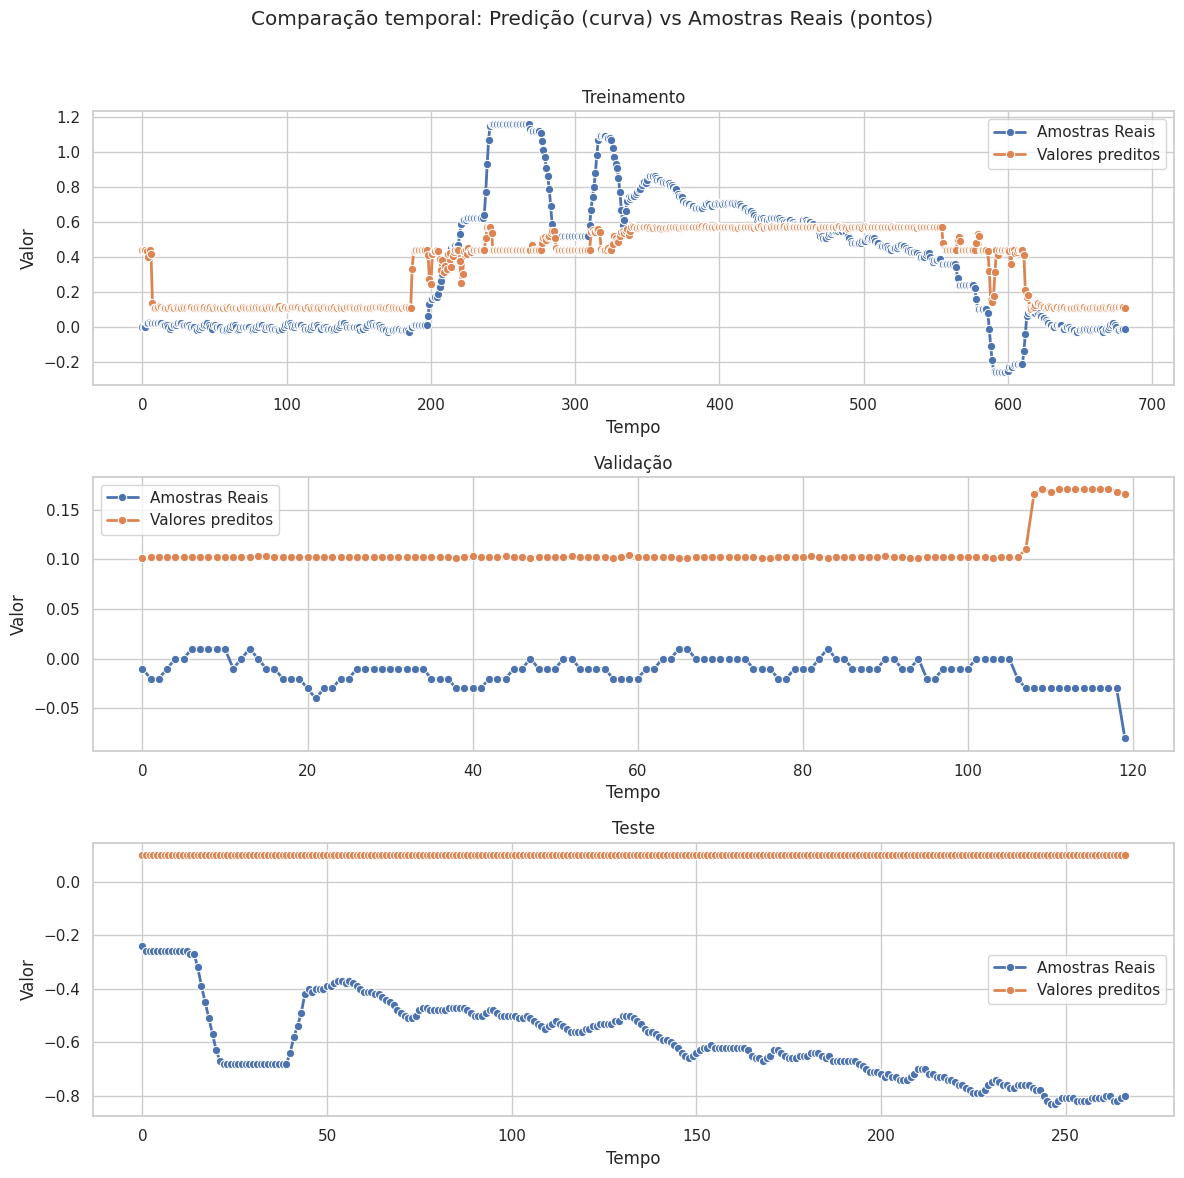

+++++++++++ [1] | 7 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


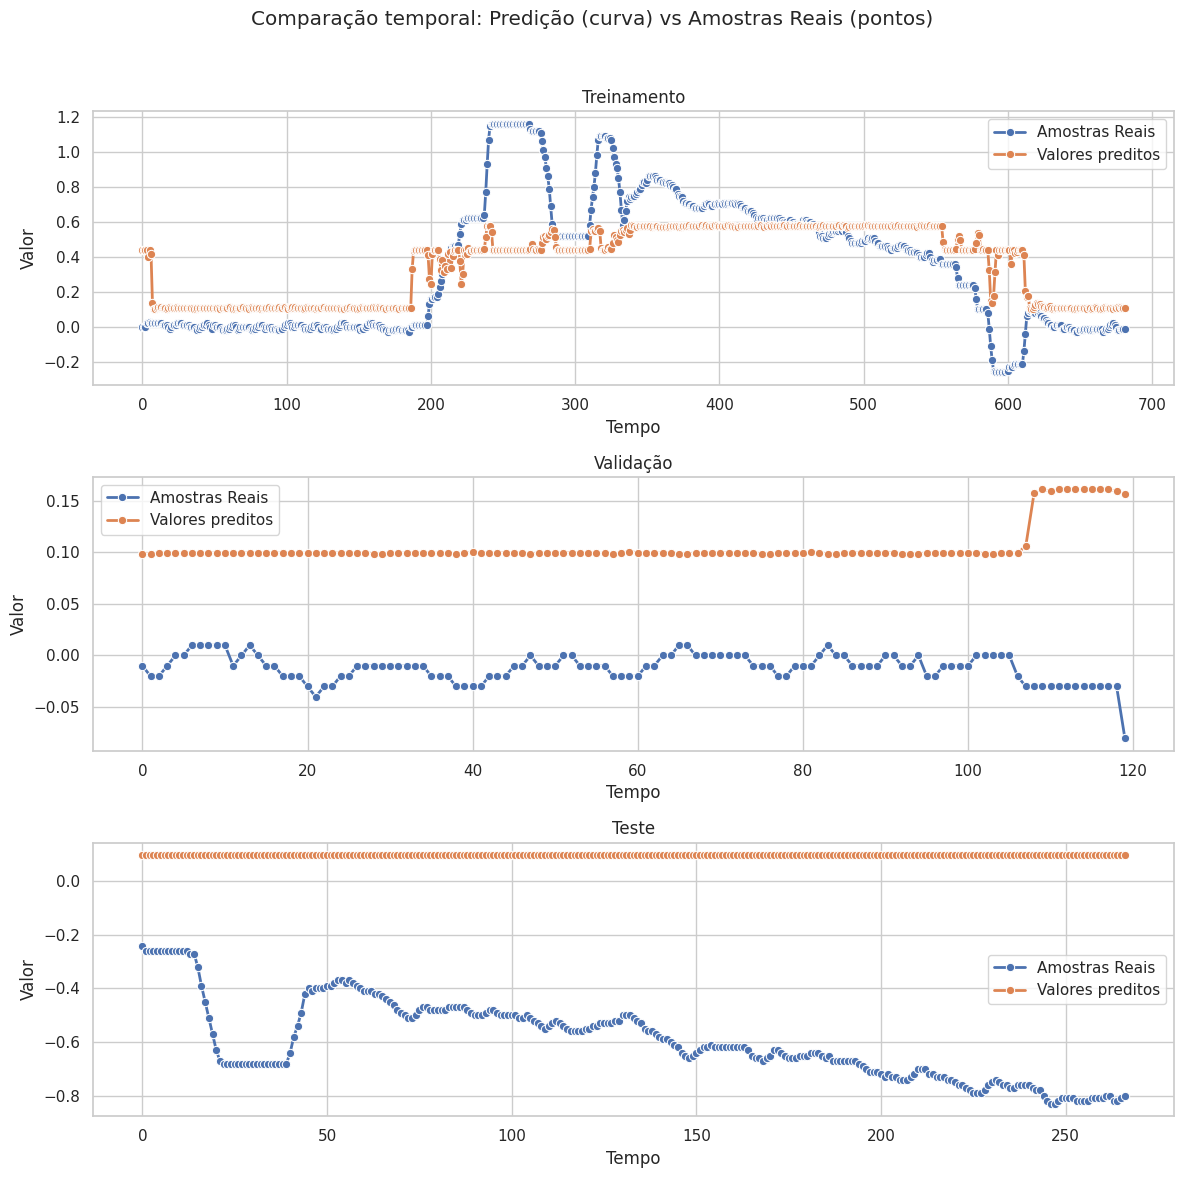

+++++++++++ [1] | 8 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


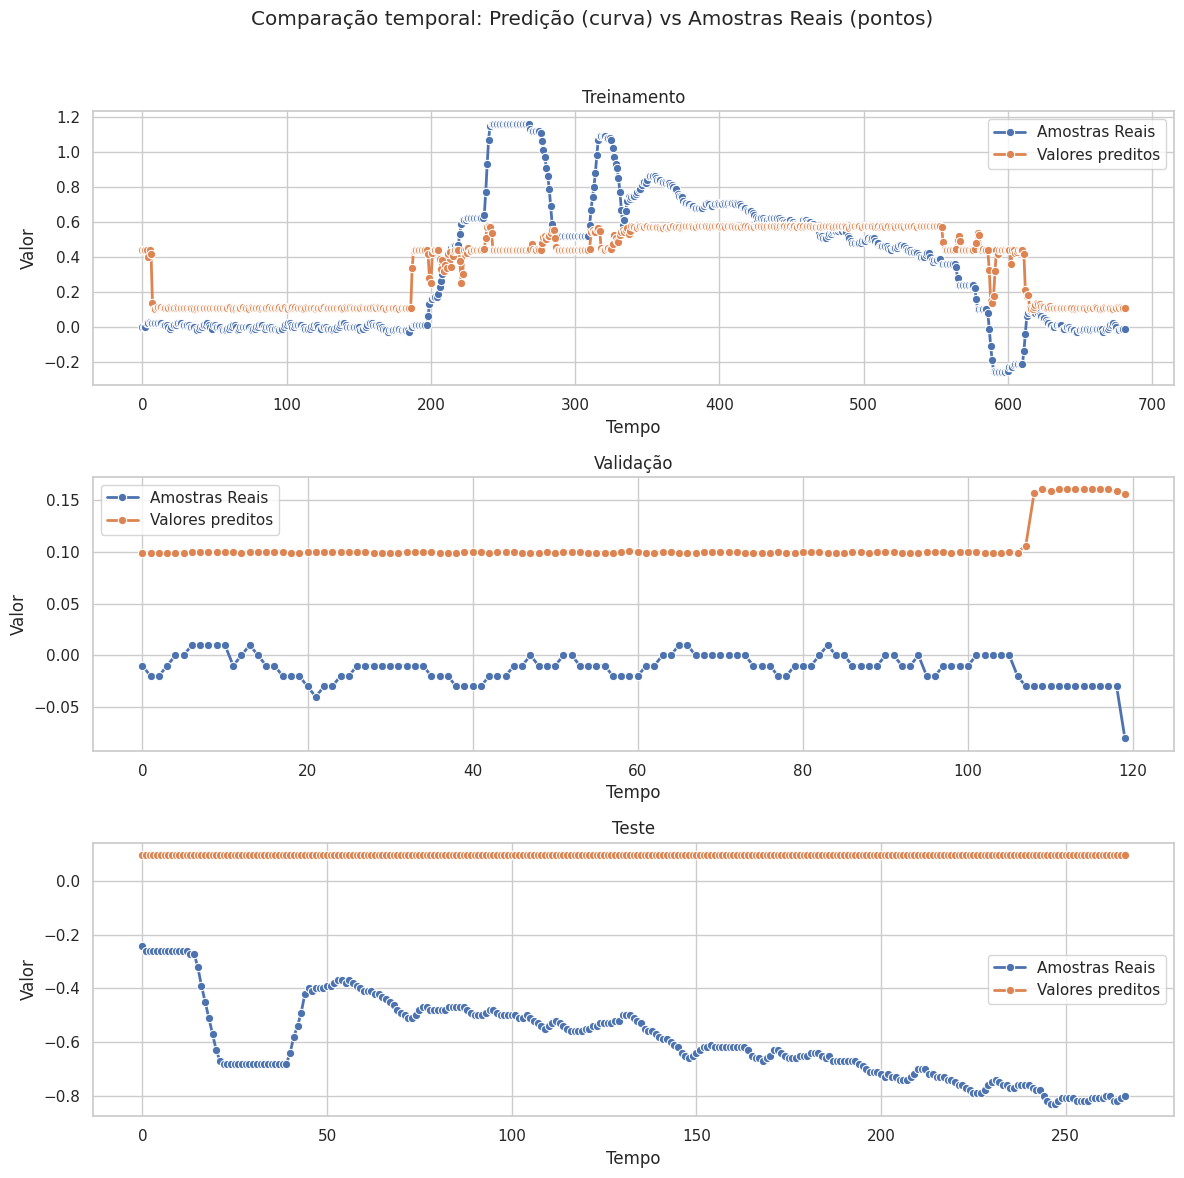

+++++++++++ [1] | 9 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


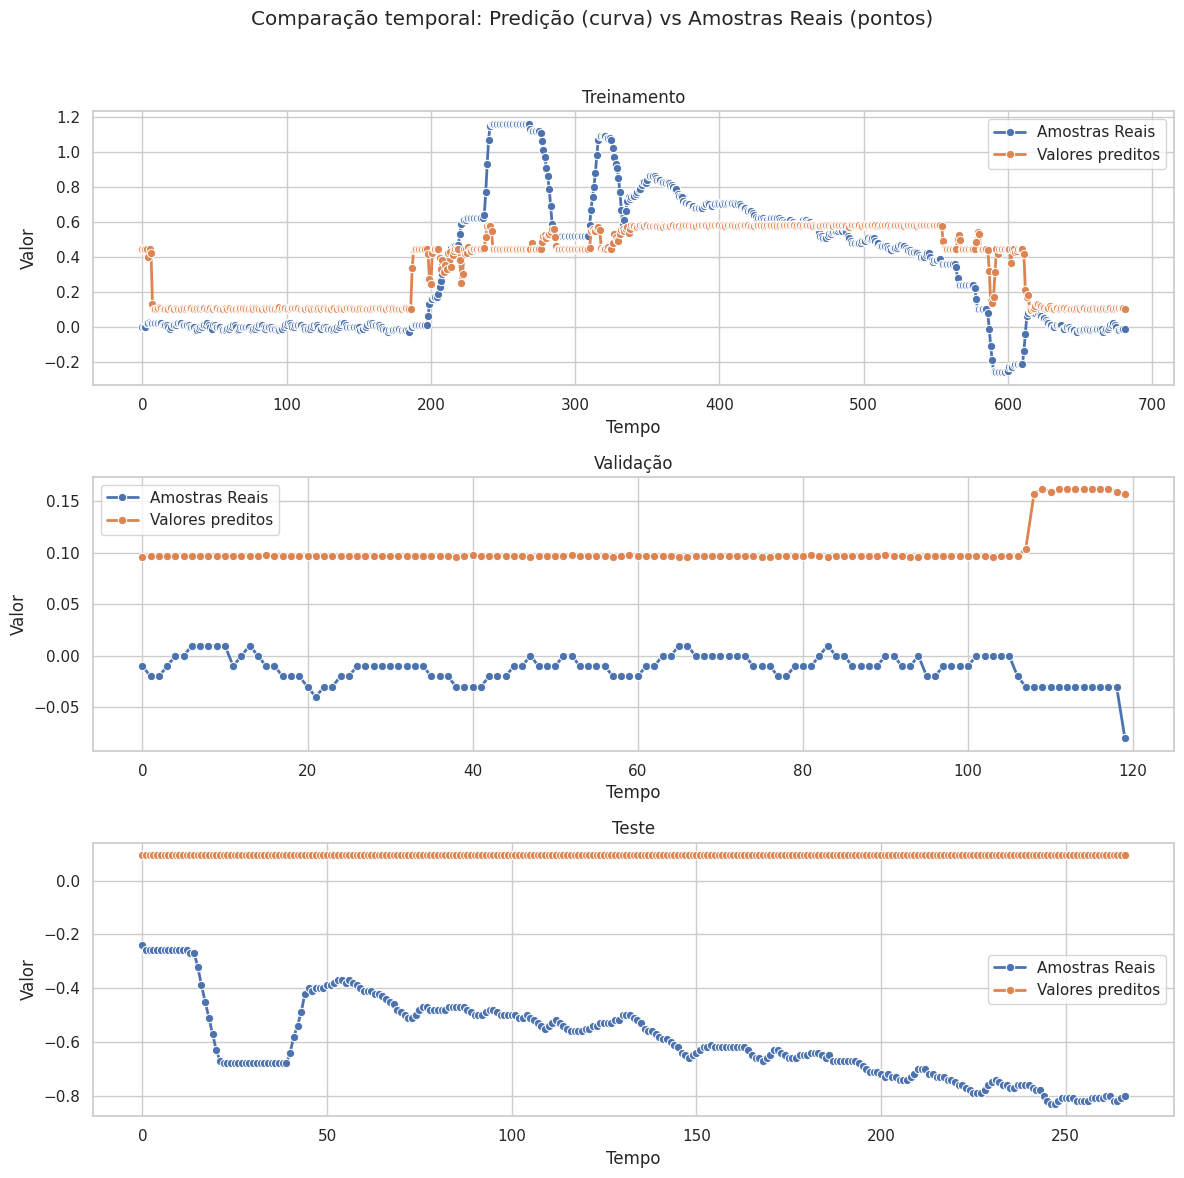

+++++++++++ [1] | 10 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


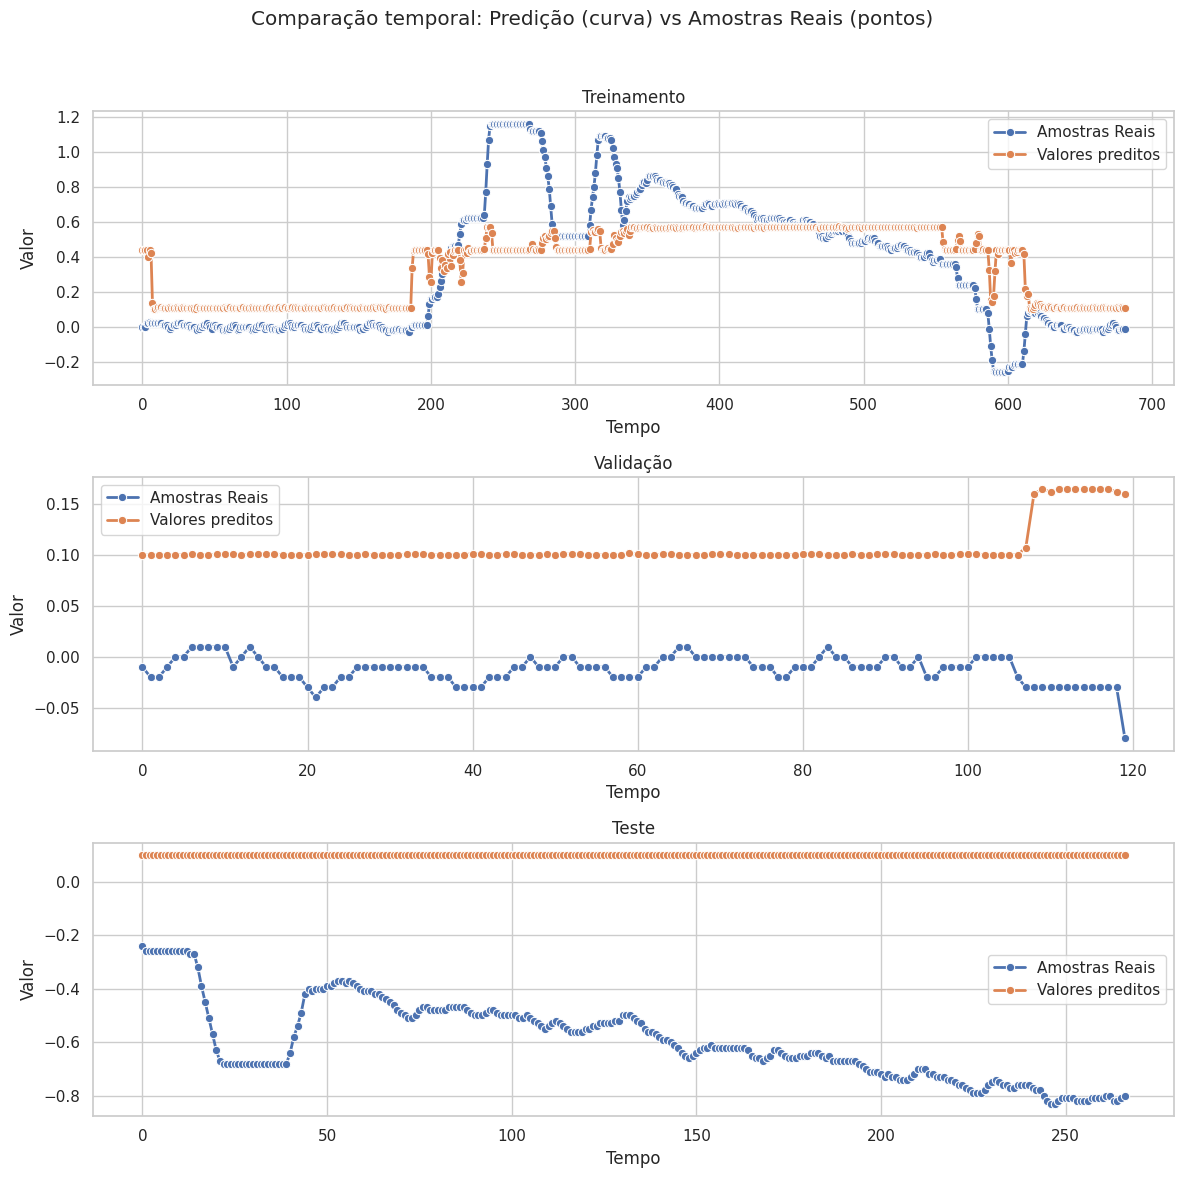

,r2_training,mse_training,mape_training,rmse_training,r2_test,mse_test,mape_test,rmse_test,r2_val,mse_val,mape_val,rmse_val
model_1_0,0.501955,0.070900,5.892956e+13,0.266270,-22.087849,0.502967,1.181356,0.709202,-89.725430,0.016164,1.053030e+14,0.127136
model_1_1,0.502859,0.070771,5.831797e+13,0.266028,-22.195710,0.505317,1.184447,0.710856,-88.433618,0.015933,1.050311e+14,0.126228
model_1_2,0.502987,0.070753,5.776660e+13,0.265994,-22.143558,0.504181,1.182956,0.710057,-86.262864,0.015547,1.036435e+14,0.124687
model_1_6,0.504238,0.070575,5.719090e+13,0.265659,-22.045457,0.502043,1.180156,0.708550,-83.006613,0.014967,1.018681e+14,0.122338
model_1_4,0.505746,0.070360,5.679243e+13,0.265254,-21.957266,0.500122,1.177604,0.707193,-80.898316,0.014591,1.007915e+14,0.120793
model_1_3,0.506879,0.070199,5.667261e+13,0.264950,-21.939114,0.499727,1.177092,0.706914,-80.551463,0.014529,1.003758e+14,0.120537
model_1_5,0.510114,0.069738,5.570316e+13,0.264080,-21.794003,0.496565,1.172902,0.704674,-78.459369,0.014156,9.824523e+13,0.118981


DataFrame salvo em ./content/results/metrics_1
Testando combinacao2: Hidden Size=[35], regularizer=0.2, learning_rate=0.01
Shape X (batch, time_steps, features): (682, 2, 2)
Shape Y (batch, output_dim): (682, 1)
Shape h0 (batch, units): (682, 35)
Shape X (batch, time_steps, features): (120, 2, 2)
Shape Y (batch, output_dim): (120, 1)
Shape h0 (batch, units): (120, 35)
Shape X (batch, time_steps, features): (267, 2, 2)
Shape Y (batch, output_dim): (267, 1)
Shape h0 (batch, units): (267, 35)
+++++++++++ [2] | 1 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
+++++++++++ [2] | 2 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
+++++++++++ [2] | 3 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


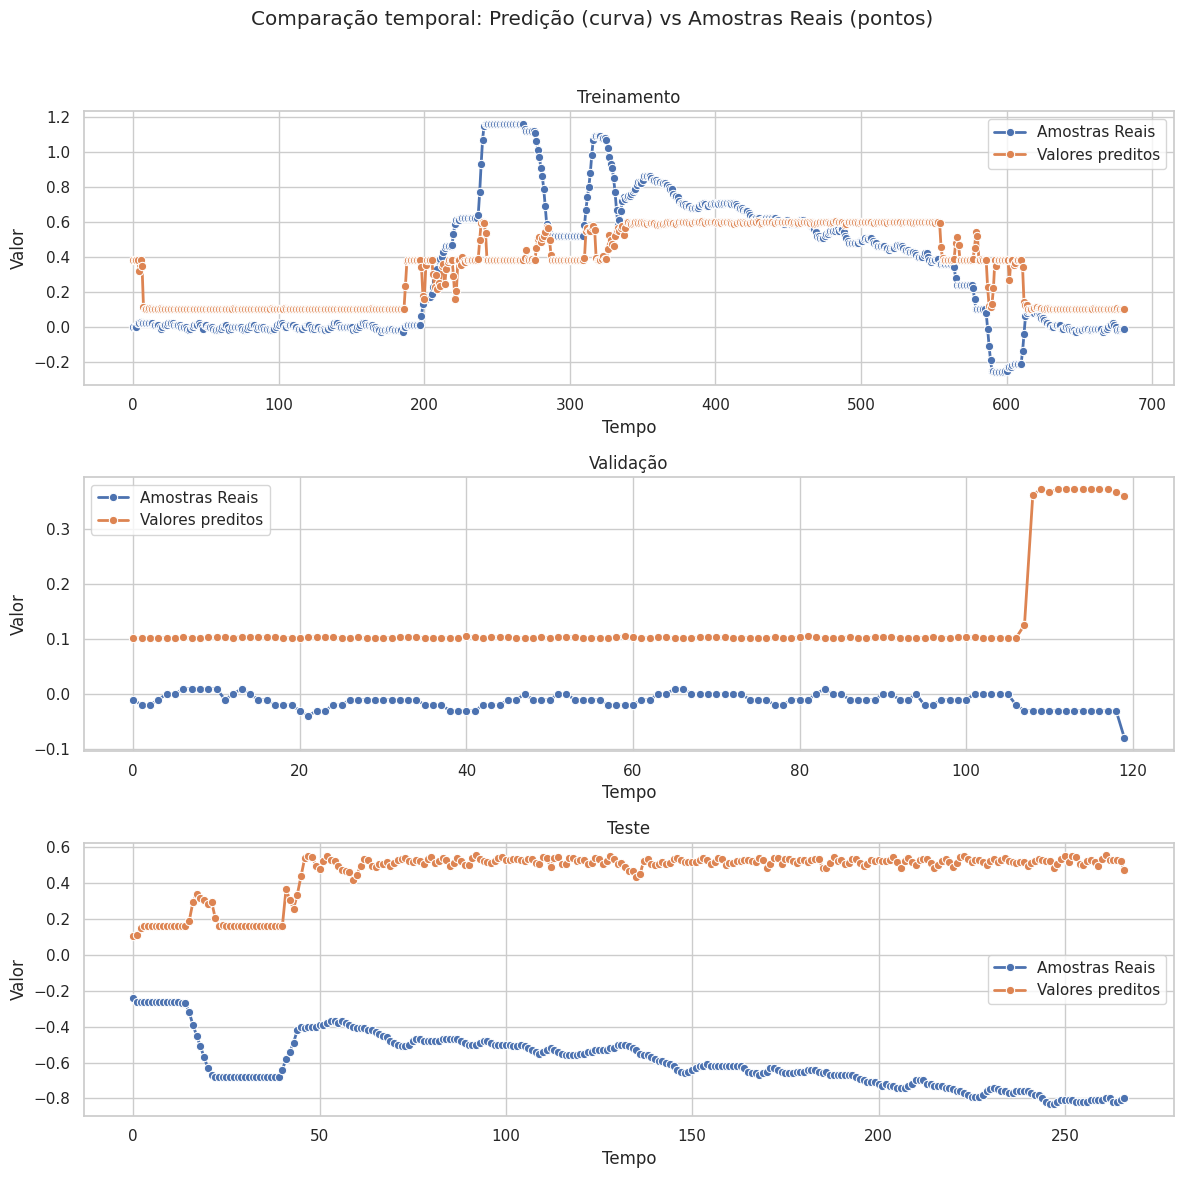

+++++++++++ [2] | 4 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


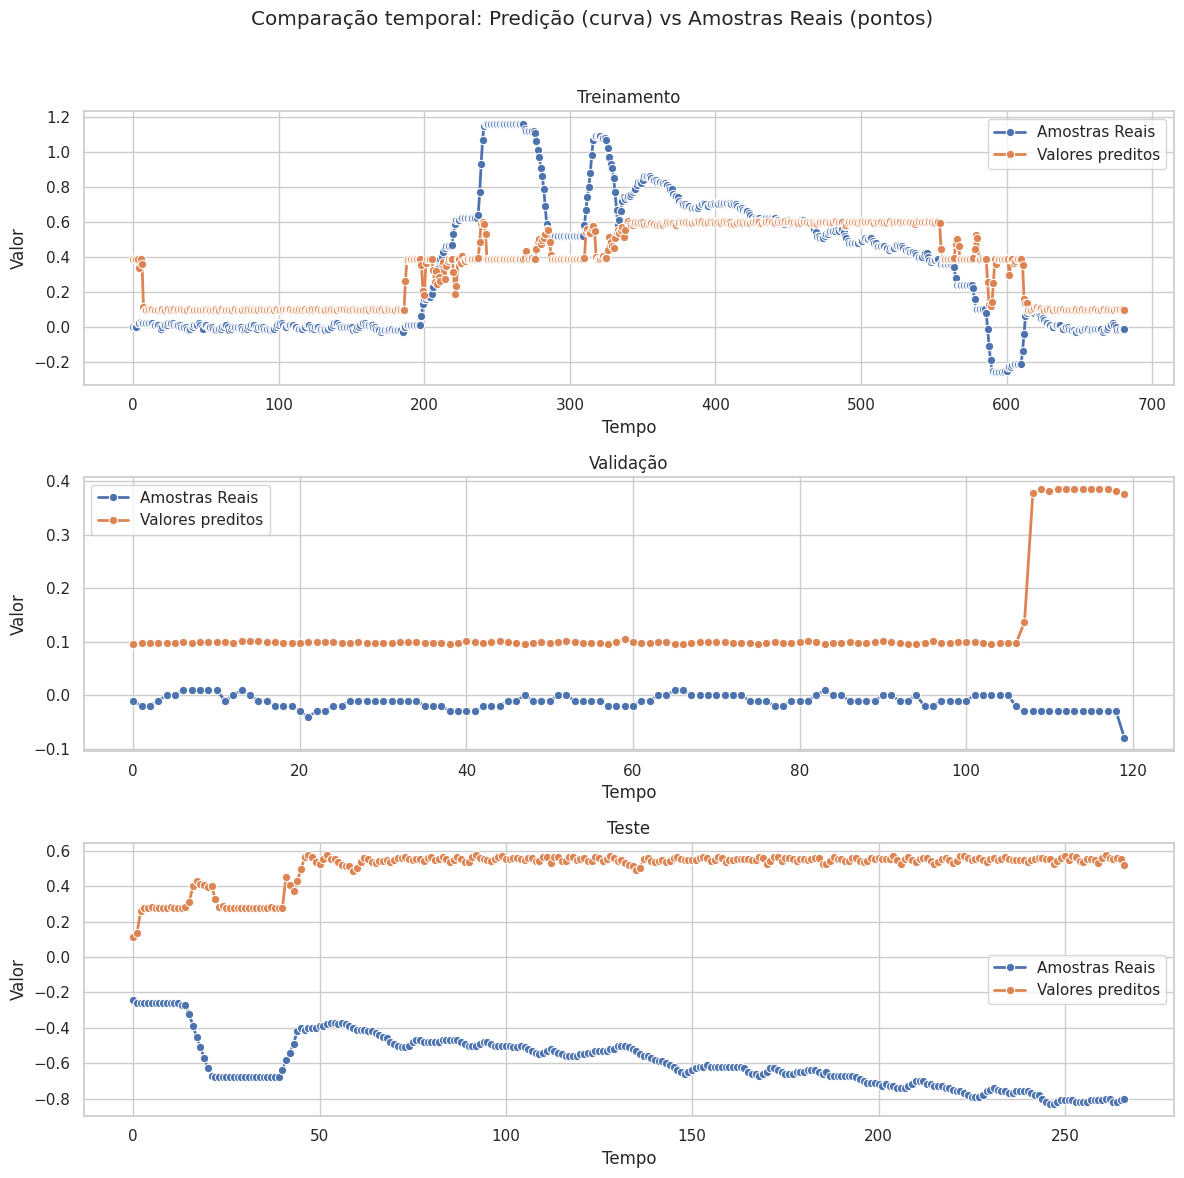

+++++++++++ [2] | 5 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


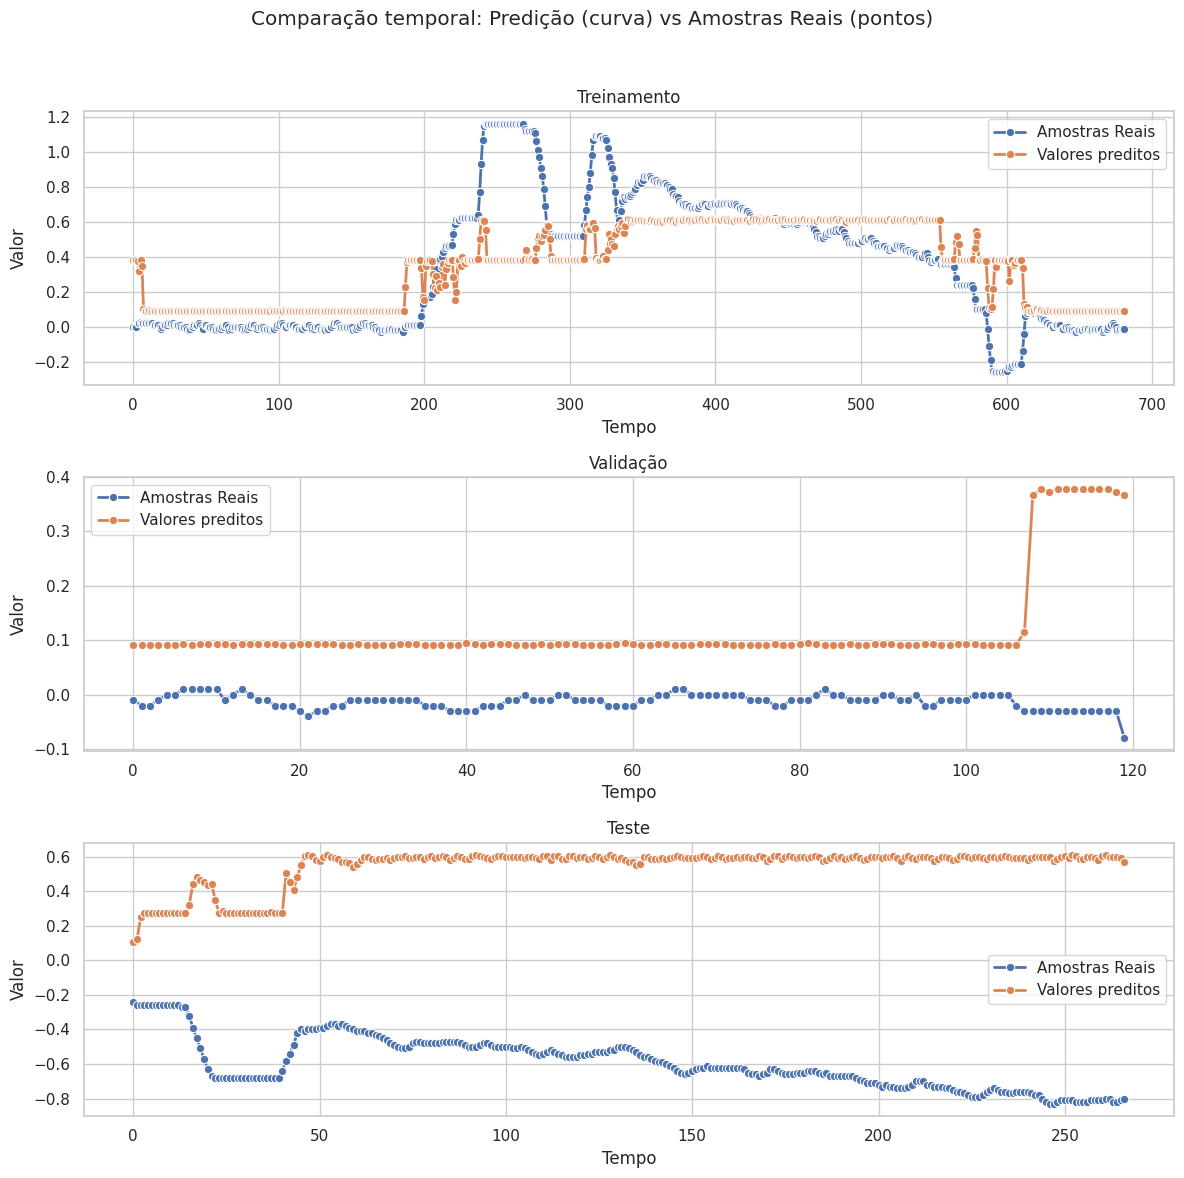

+++++++++++ [2] | 6 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


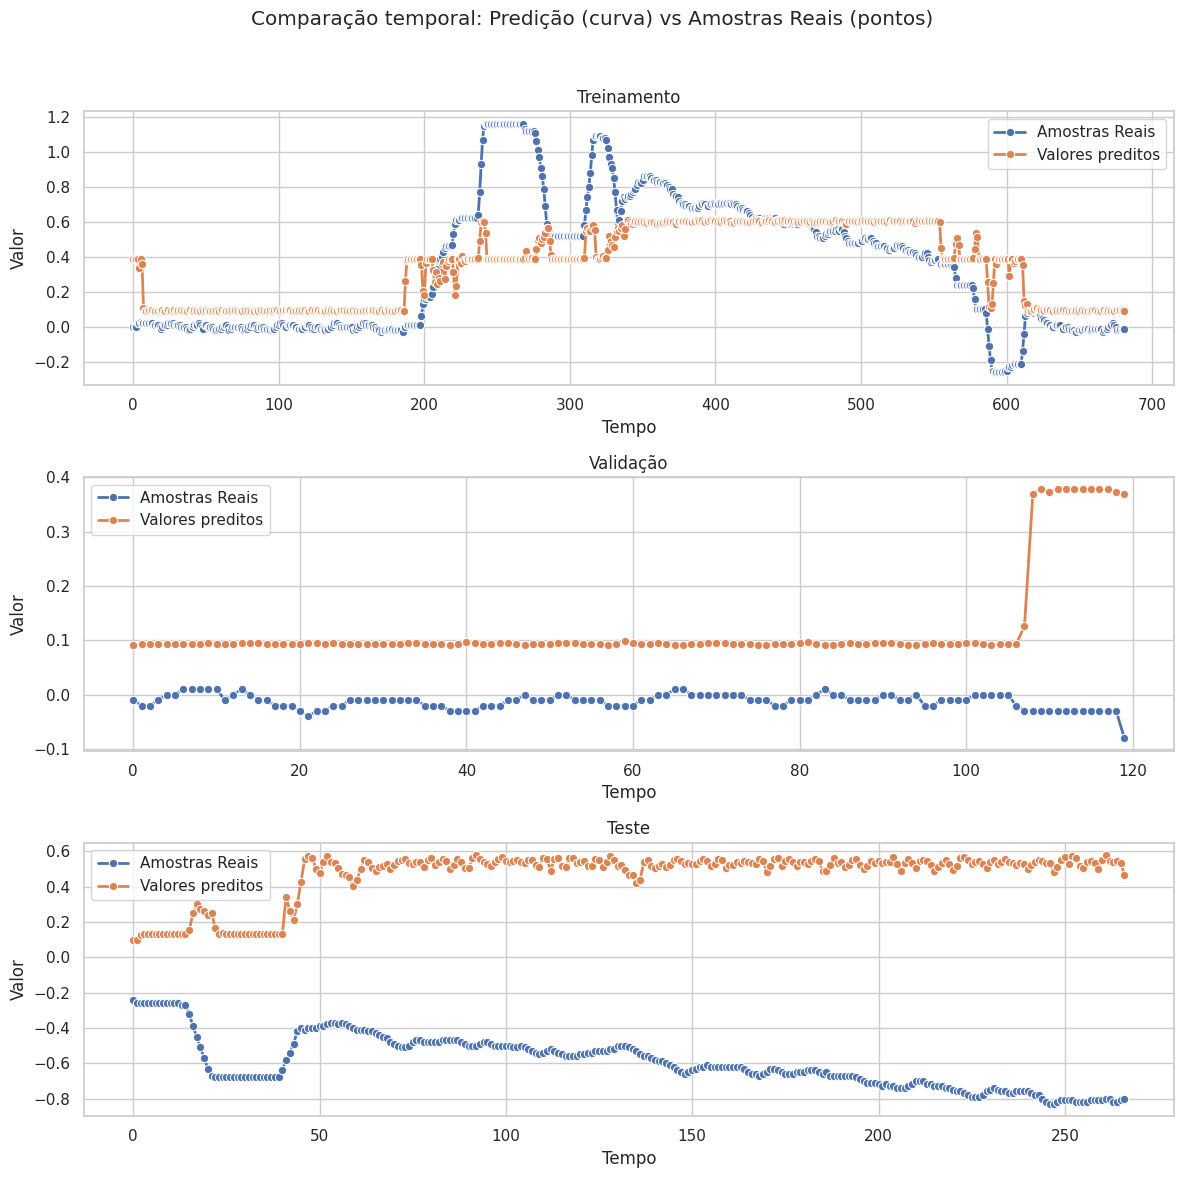

+++++++++++ [2] | 7 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


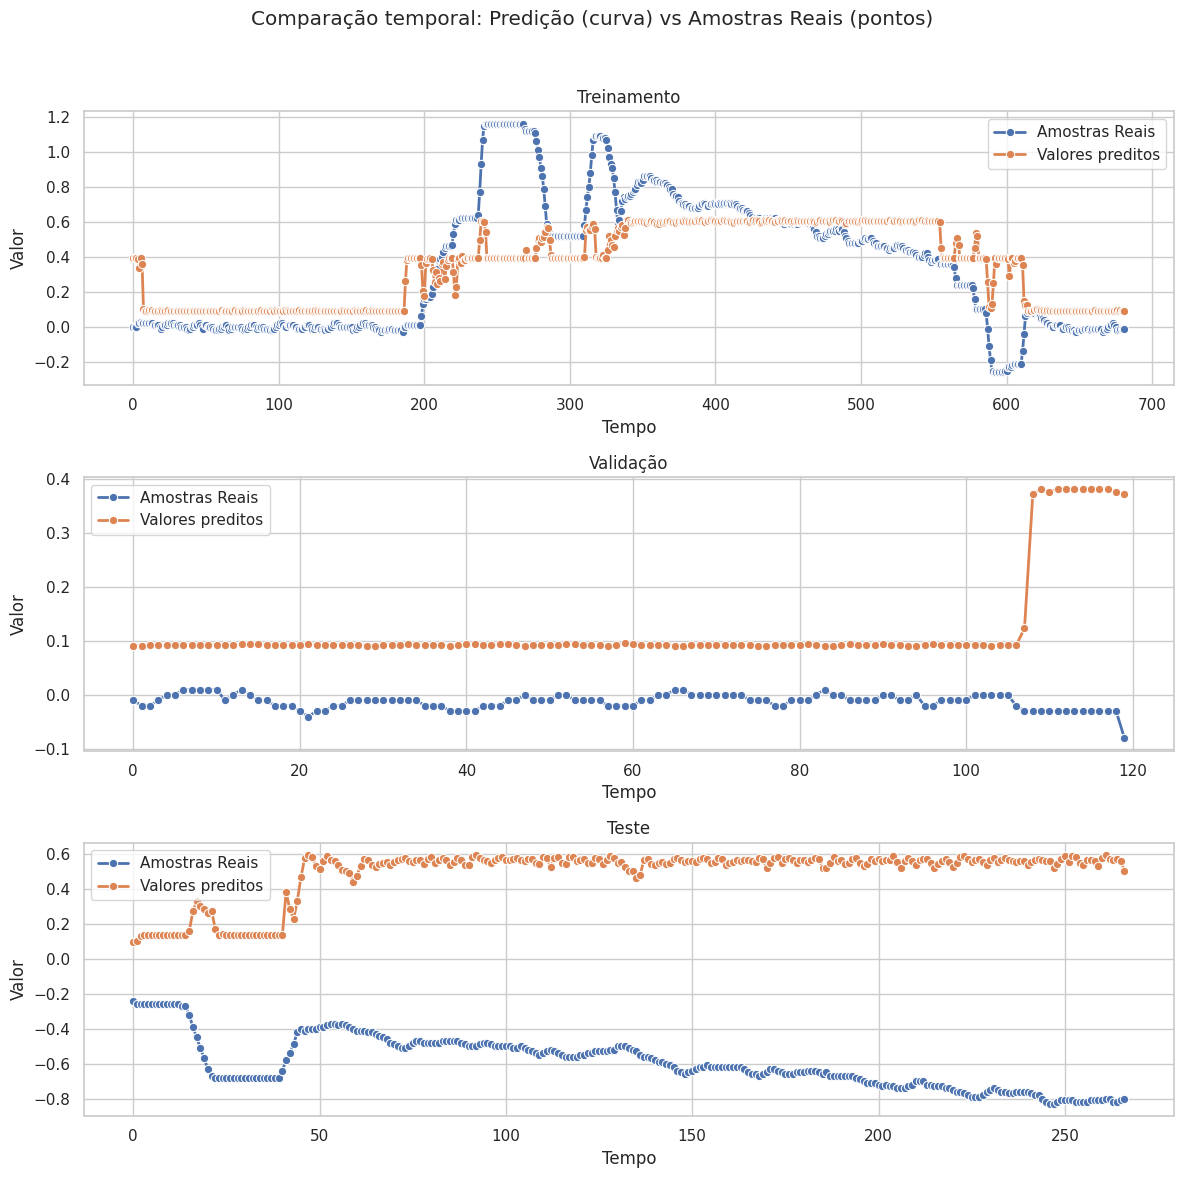

+++++++++++ [2] | 8 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


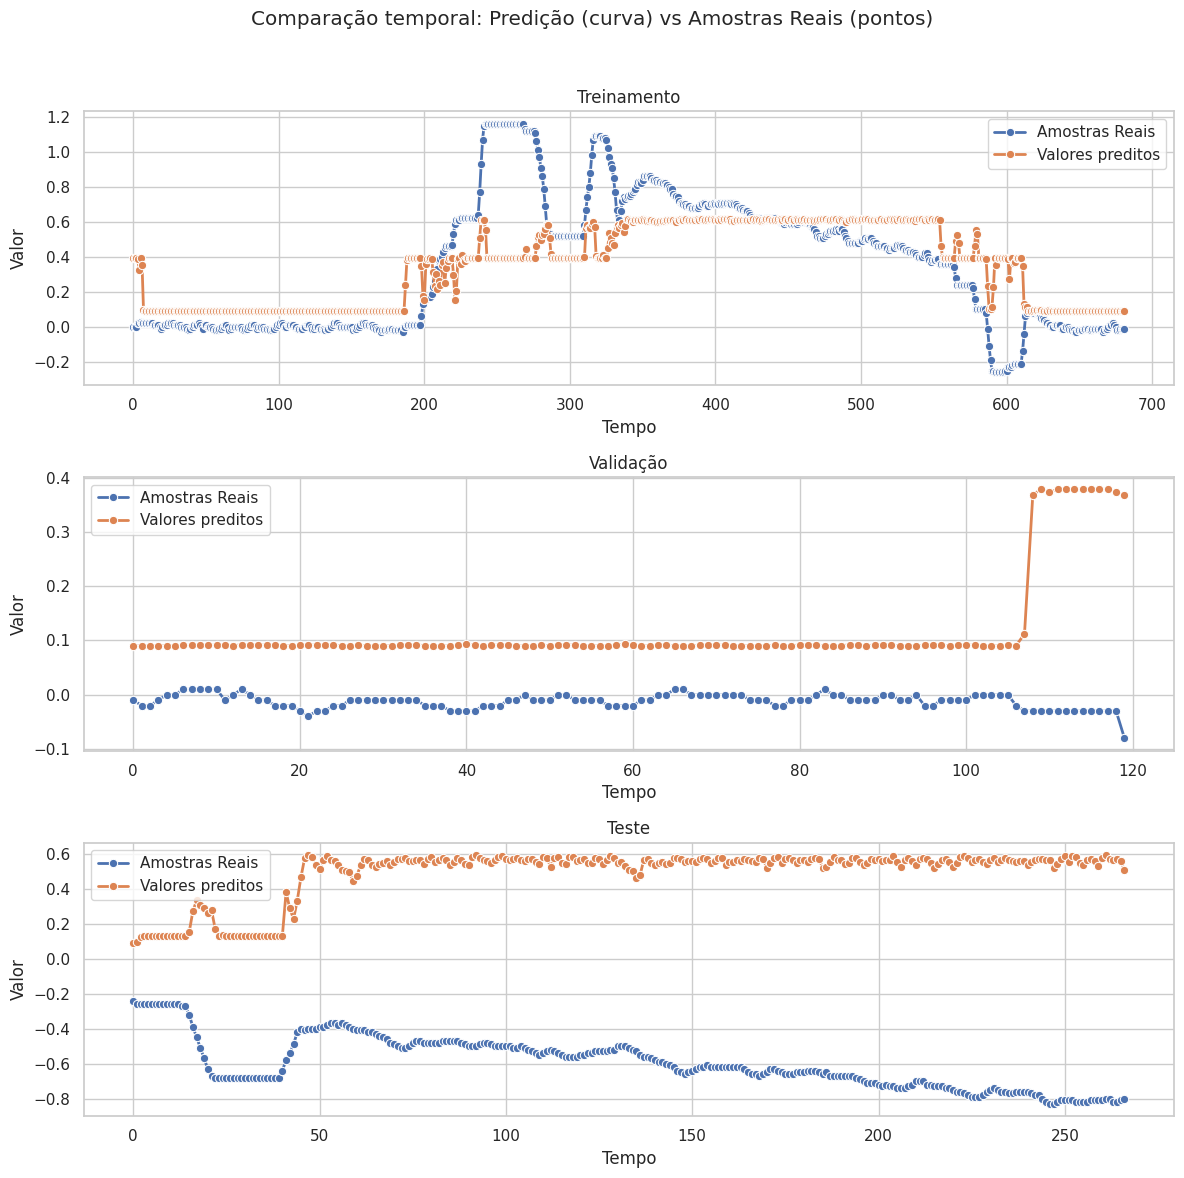

+++++++++++ [2] | 9 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


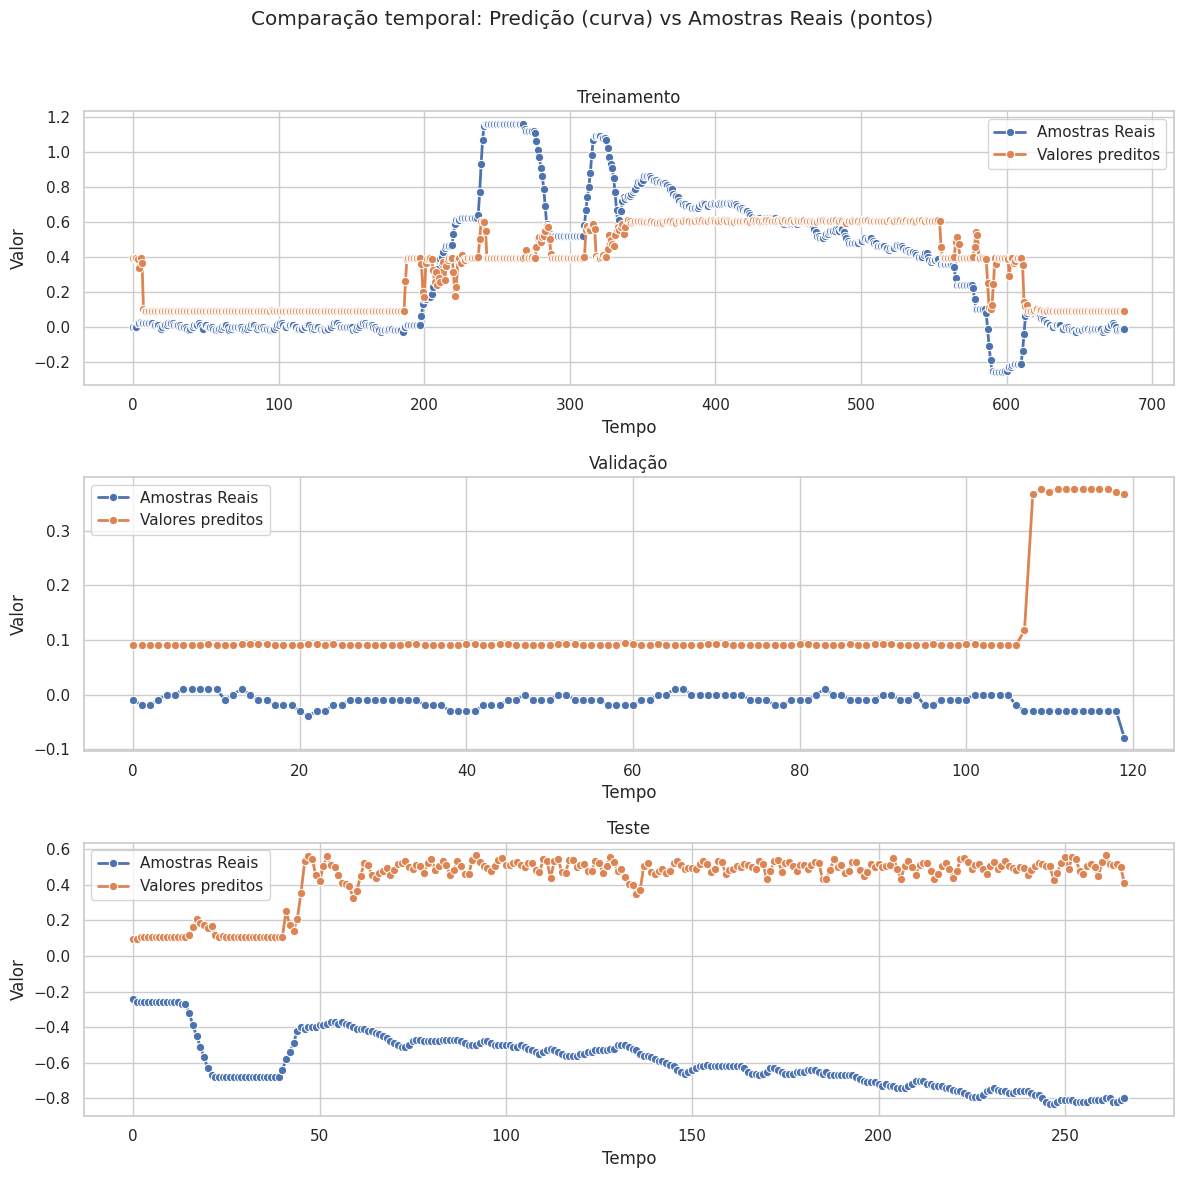

+++++++++++ [2] | 10 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


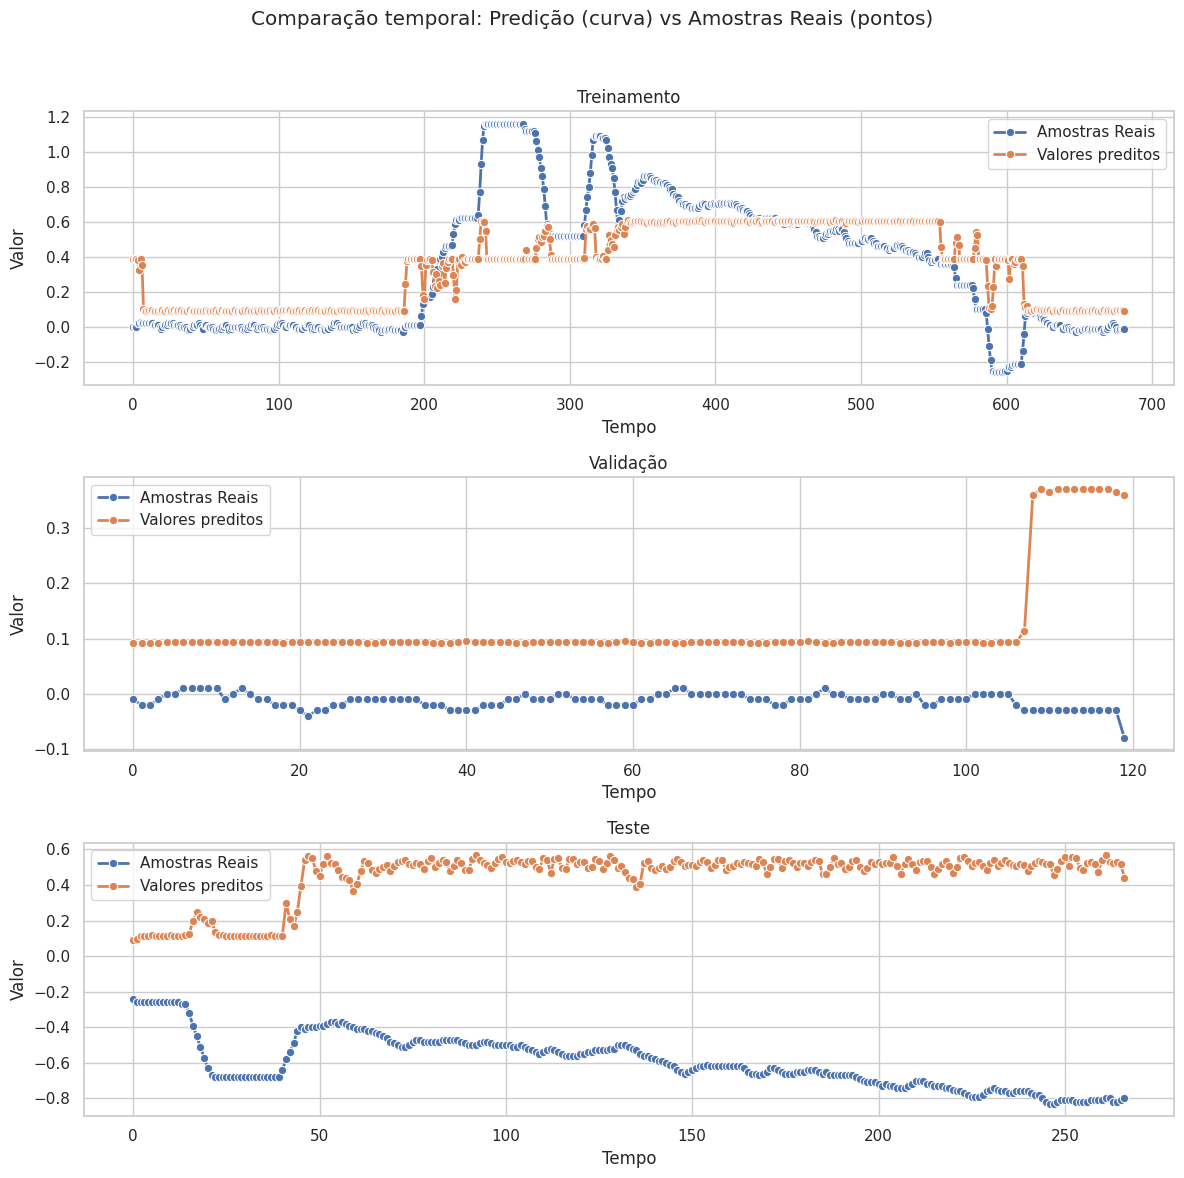

,r2_training,mse_training,mape_training,rmse_training,r2_test,mse_test,mape_test,rmse_test,r2_val,mse_val,mape_val,rmse_val
model_2_0,0.500321,0.071132,5.300588e+13,0.266706,-52.660431,1.168988,1.809744,1.081198,-155.658377,0.027910,1.043648e+14,0.167063
model_2_1,0.501482,0.070967,5.148733e+13,0.266396,-56.817909,1.259558,1.901051,1.122300,-157.365418,0.028214,1.001495e+14,0.167971
model_1_0,0.501955,0.070900,5.892956e+13,0.266270,-22.087849,0.502967,1.181356,0.709202,-89.725430,0.016164,1.053030e+14,0.127136
model_1_1,0.502859,0.070771,5.831797e+13,0.266028,-22.195710,0.505317,1.184447,0.710856,-88.433618,0.015933,1.050311e+14,0.126228
model_1_2,0.502987,0.070753,5.776660e+13,0.265994,-22.143558,0.504181,1.182956,0.710057,-86.262864,0.015547,1.036435e+14,0.124687
model_1_6,0.504238,0.070575,5.719090e+13,0.265659,-22.045457,0.502043,1.180156,0.708550,-83.006613,0.014967,1.018681e+14,0.122338
model_2_3,0.505707,0.070365,4.919401e+13,0.265265,-53.417100,1.185472,1.814969,1.088794,-148.023754,0.026550,9.476425e+13,0.162942
model_1_4,0.505746,0.070360,5.679243e+13,0.265254,-21.957266,0.500122,1.177604,0.707193,-80.898316,0.014591,1.007915e+14,0.120793
model_2_7,0.506648,0.070232,4.886227e+13,0.265012,-51.588531,1.145637,1.779503,1.070344,-143.954733,0.025825,9.458789e+13,0.160702
model_2_2,0.506877,0.070199,4.813678e+13,0.264951,-60.625816,1.342513,1.960849,1.158669,-146.191071,0.026224,9.347628e+13,0.161937


DataFrame salvo em ./content/results/metrics_2
Testando combinacao3: Hidden Size=[40], regularizer=0.2, learning_rate=0.01
Shape X (batch, time_steps, features): (682, 2, 2)
Shape Y (batch, output_dim): (682, 1)
Shape h0 (batch, units): (682, 40)
Shape X (batch, time_steps, features): (120, 2, 2)
Shape Y (batch, output_dim): (120, 1)
Shape h0 (batch, units): (120, 40)
Shape X (batch, time_steps, features): (267, 2, 2)
Shape Y (batch, output_dim): (267, 1)
Shape h0 (batch, units): (267, 40)
+++++++++++ [3] | 1 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
+++++++++++ [3] | 2 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
+++++++++++ [3] | 3 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


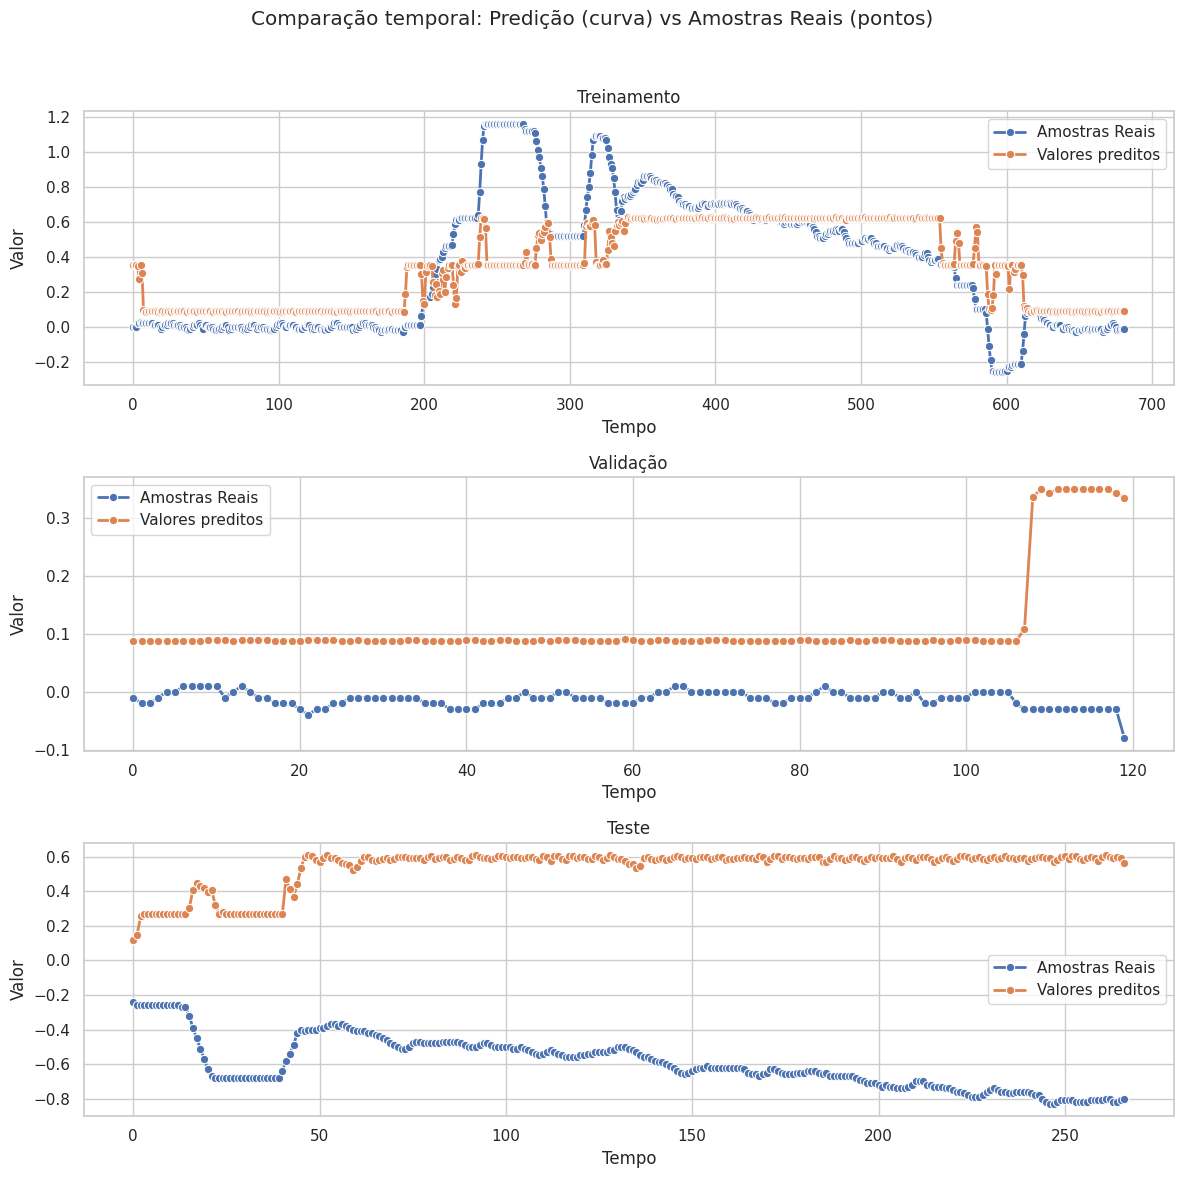

+++++++++++ [3] | 4 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


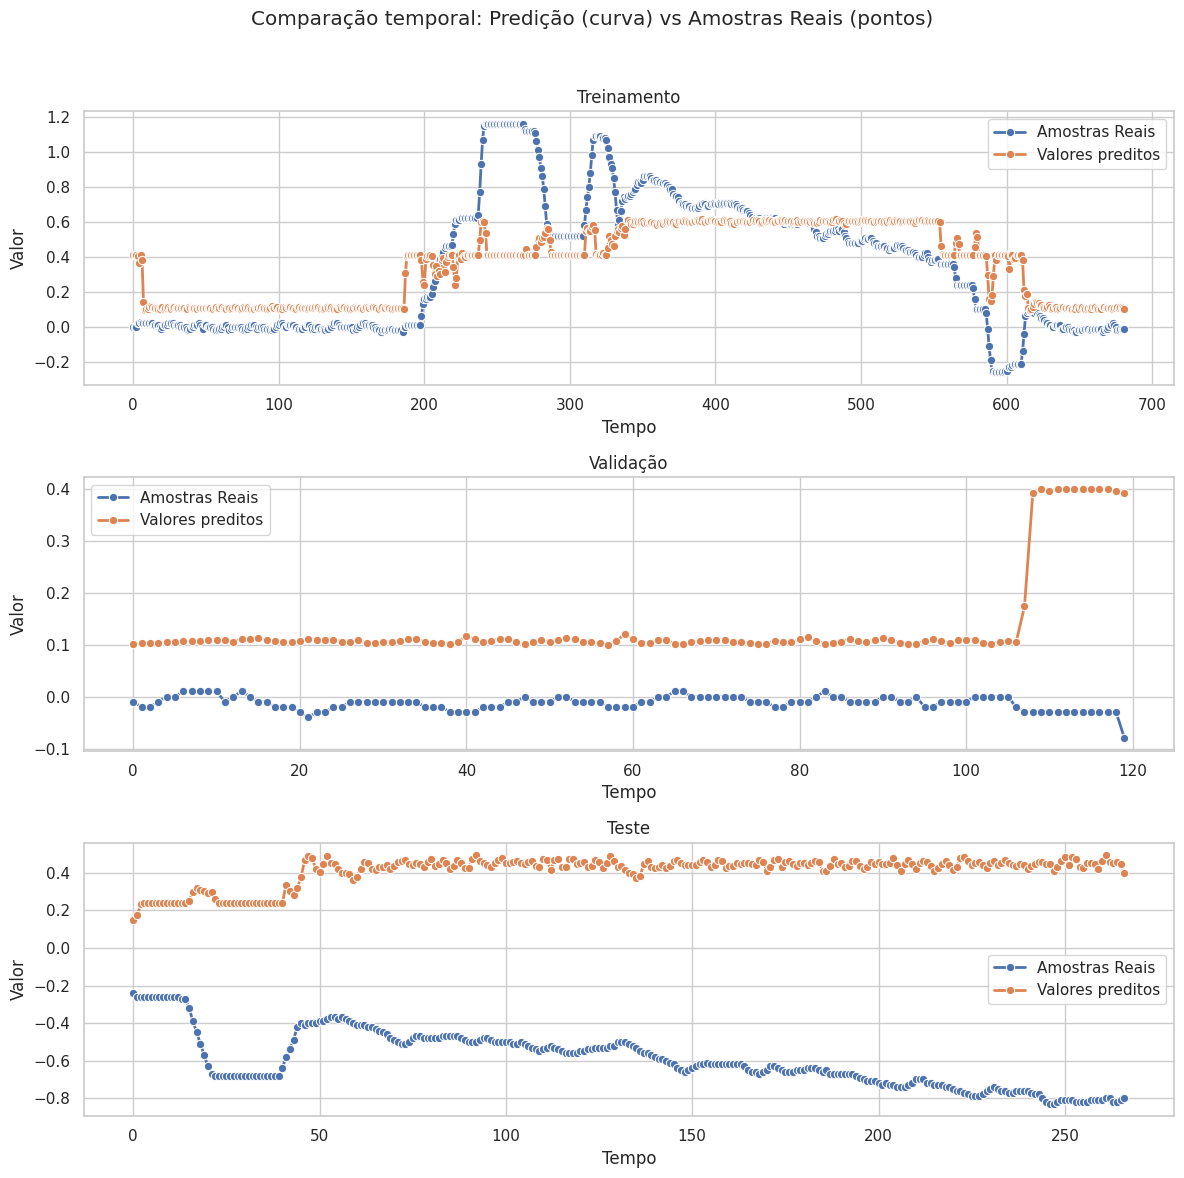

+++++++++++ [3] | 5 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


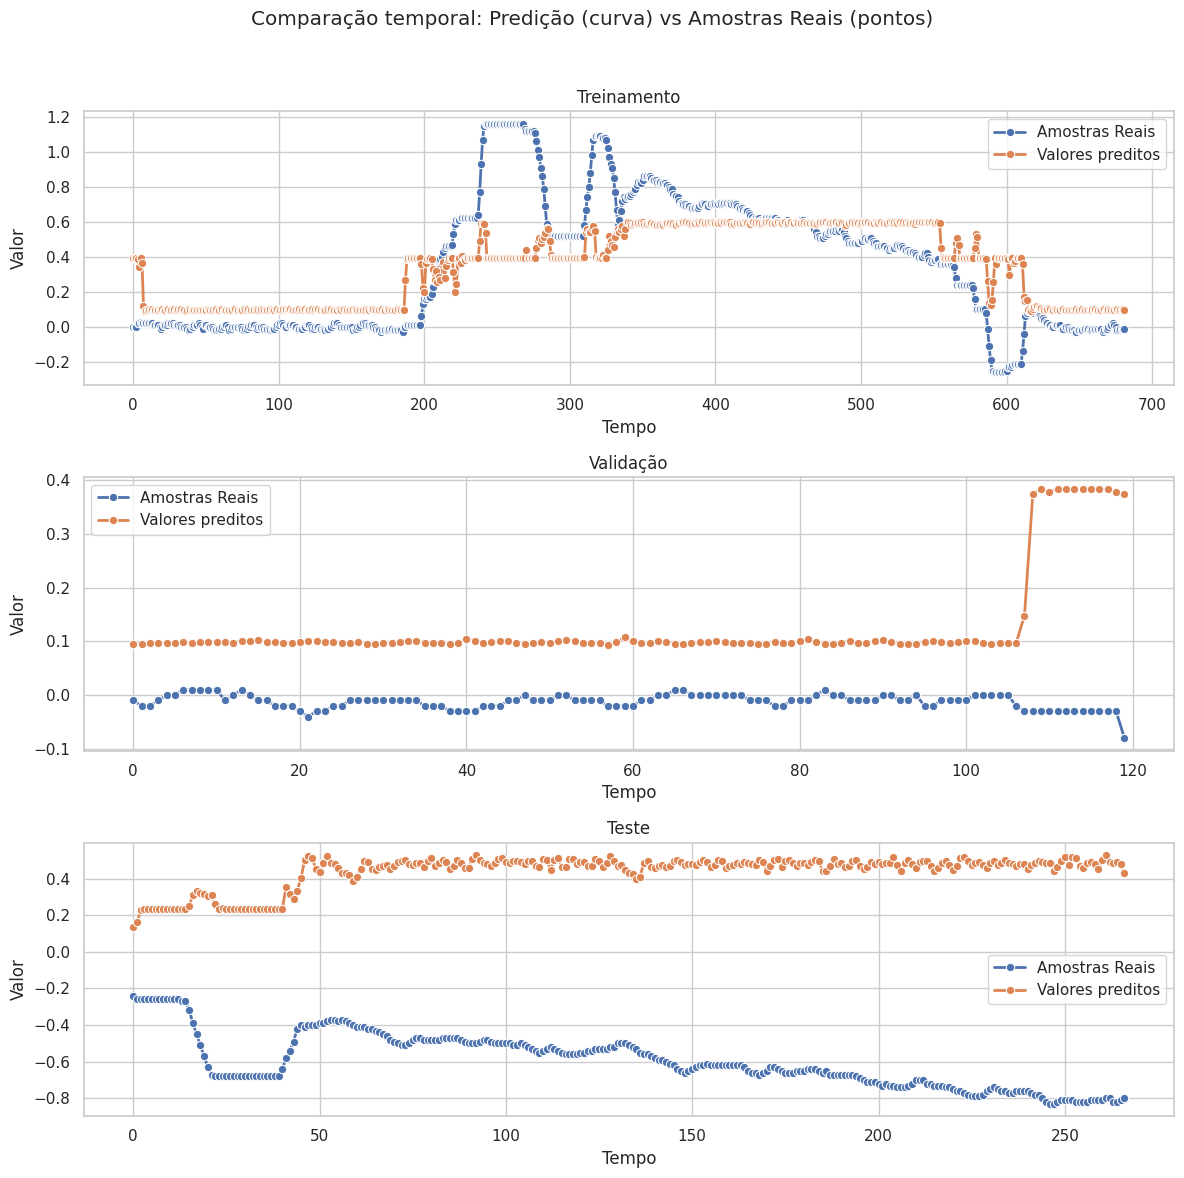

+++++++++++ [3] | 6 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
+++++++++++ [3] | 7 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


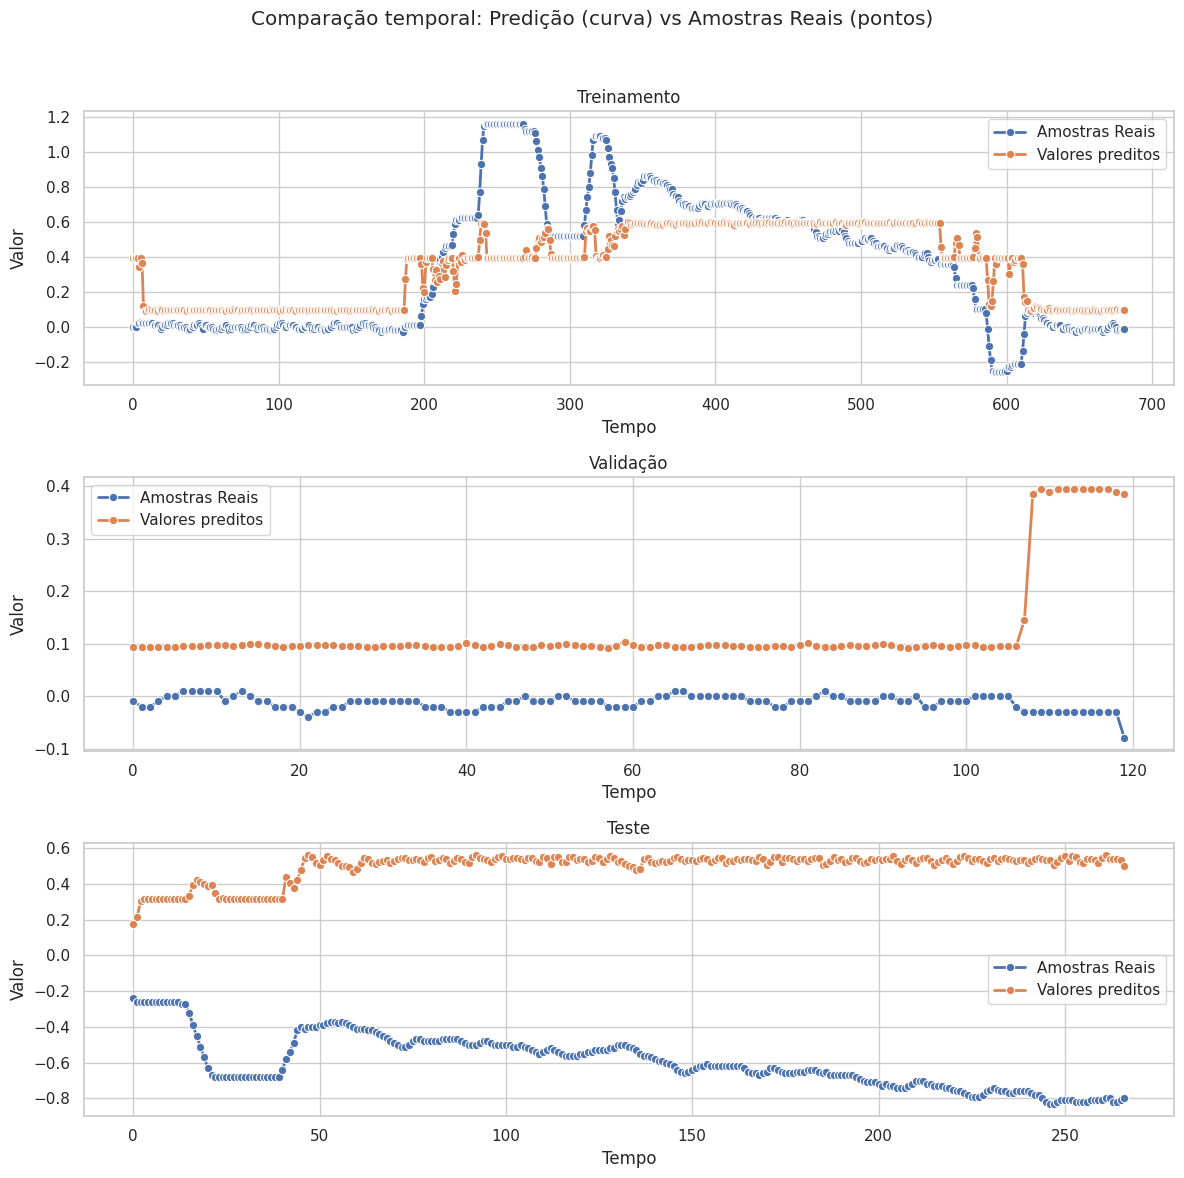

+++++++++++ [3] | 8 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
+++++++++++ [3] | 9 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


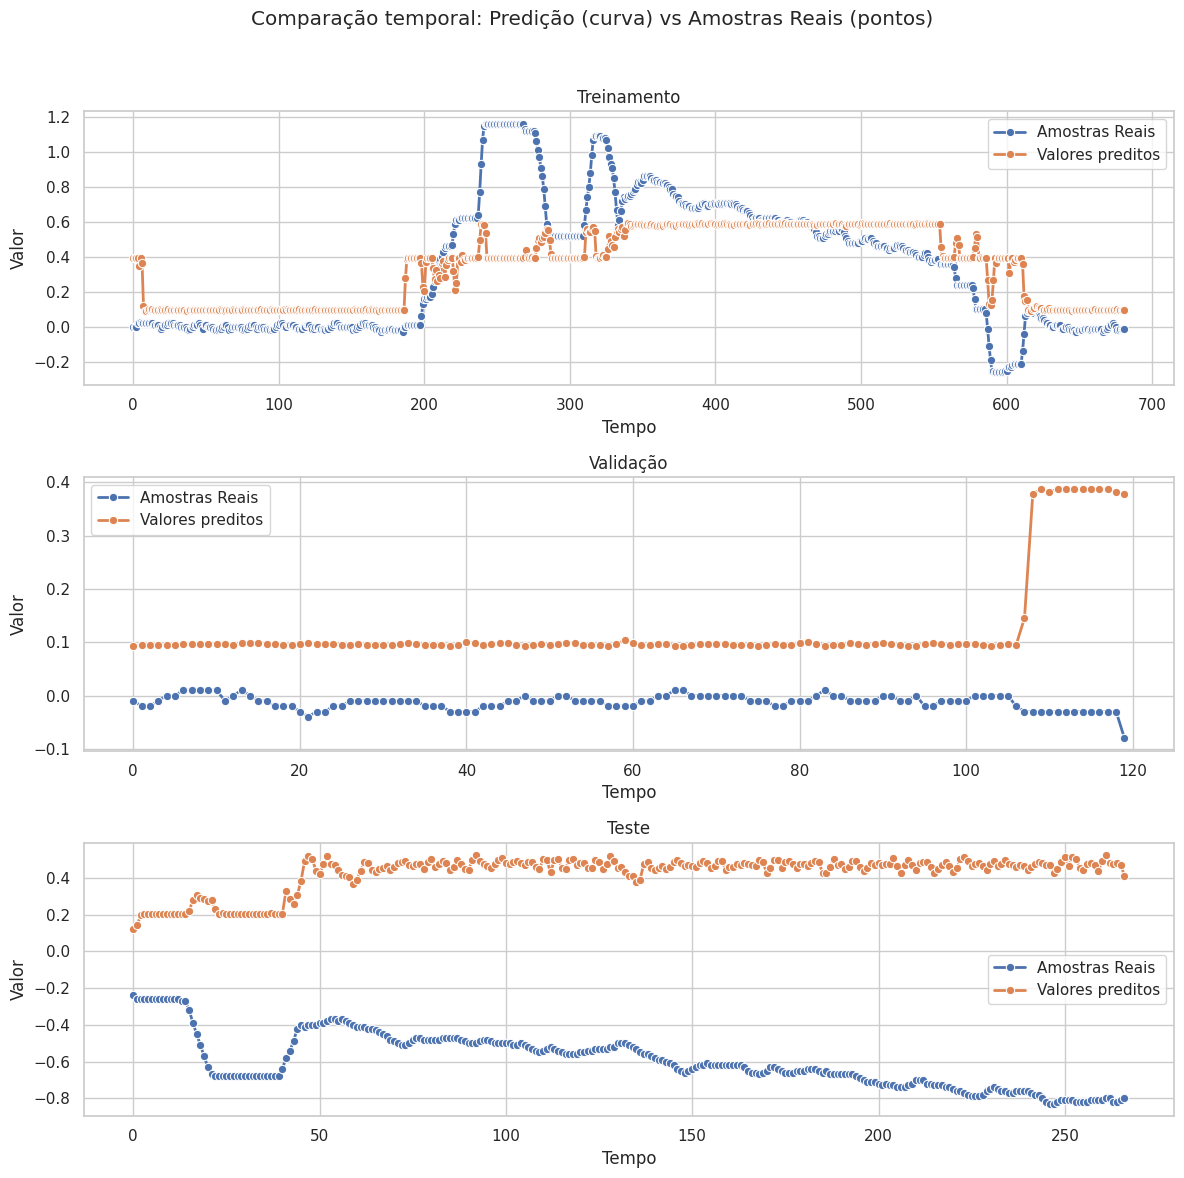

+++++++++++ [3] | 10 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


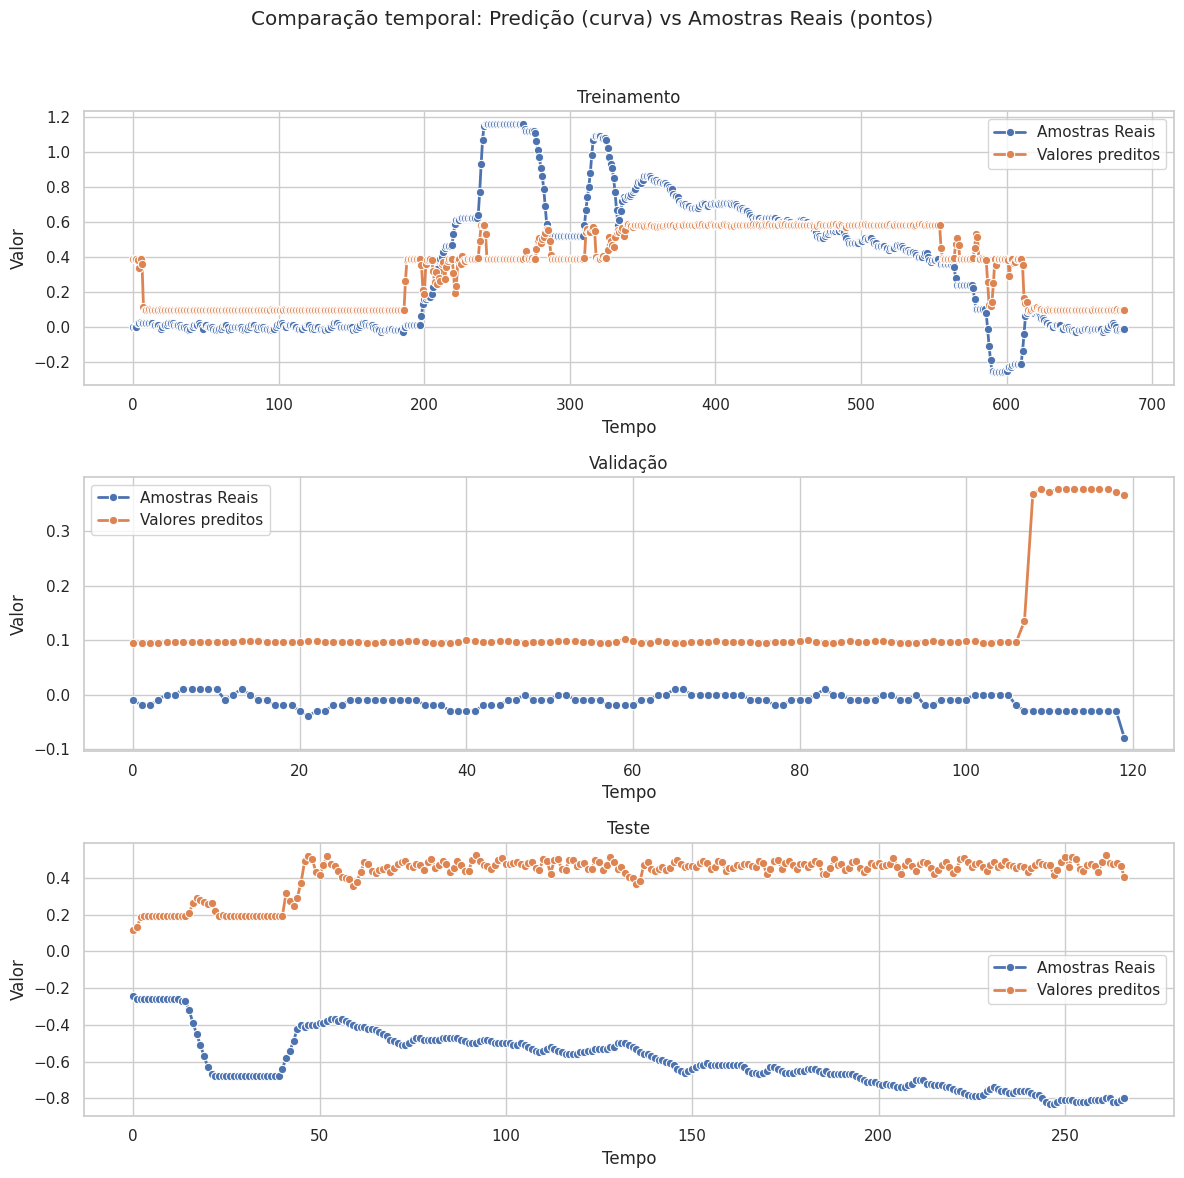

,r2_training,mse_training,mape_training,rmse_training,r2_test,mse_test,mape_test,rmse_test,r2_val,mse_val,mape_val,rmse_val
model_2_0,0.500321,0.071132,5.300588e+13,0.266706,-52.660431,1.168988,1.809744,1.081198,-155.658377,0.027910,1.043648e+14,0.167063
model_3_0,0.500656,0.071085,4.582804e+13,0.266617,-60.305983,1.335546,1.954614,1.155658,-130.148863,0.023365,8.980267e+13,0.152858
model_2_1,0.501482,0.070967,5.148733e+13,0.266396,-56.817909,1.259558,1.901051,1.122300,-157.365418,0.028214,1.001495e+14,0.167971
model_3_1,0.501730,0.070932,5.605354e+13,0.266330,-47.188188,1.049776,1.731521,1.024586,-174.101368,0.031196,1.083697e+14,0.176624
model_3_5,0.501739,0.070930,5.043915e+13,0.266328,-48.340688,1.074883,1.741694,1.036766,-150.668751,0.027021,9.777720e+13,0.164381
model_1_0,0.501955,0.070900,5.892956e+13,0.266270,-22.087849,0.502967,1.181356,0.709202,-89.725430,0.016164,1.053030e+14,0.127136
model_1_1,0.502859,0.070771,5.831797e+13,0.266028,-22.195710,0.505317,1.184447,0.710856,-88.433618,0.015933,1.050311e+14,0.126228
model_3_2,0.502901,0.070765,5.138090e+13,0.266017,-49.962896,1.110223,1.778596,1.053671,-155.501955,0.027882,9.944191e+13,0.166980
model_1_2,0.502987,0.070753,5.776660e+13,0.265994,-22.143558,0.504181,1.182956,0.710057,-86.262864,0.015547,1.036435e+14,0.124687
model_1_6,0.504238,0.070575,5.719090e+13,0.265659,-22.045457,0.502043,1.180156,0.708550,-83.006613,0.014967,1.018681e+14,0.122338


DataFrame salvo em ./content/results/metrics_3
Testando combinacao4: Hidden Size=[45], regularizer=0.2, learning_rate=0.01
Shape X (batch, time_steps, features): (682, 2, 2)
Shape Y (batch, output_dim): (682, 1)
Shape h0 (batch, units): (682, 45)
Shape X (batch, time_steps, features): (120, 2, 2)
Shape Y (batch, output_dim): (120, 1)
Shape h0 (batch, units): (120, 45)
Shape X (batch, time_steps, features): (267, 2, 2)
Shape Y (batch, output_dim): (267, 1)
Shape h0 (batch, units): (267, 45)
+++++++++++ [4] | 1 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
+++++++++++ [4] | 2 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
+++++++++++ [4] | 3 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
+++++++++++ [4] | 4 ++++++++++++++++++
22/2

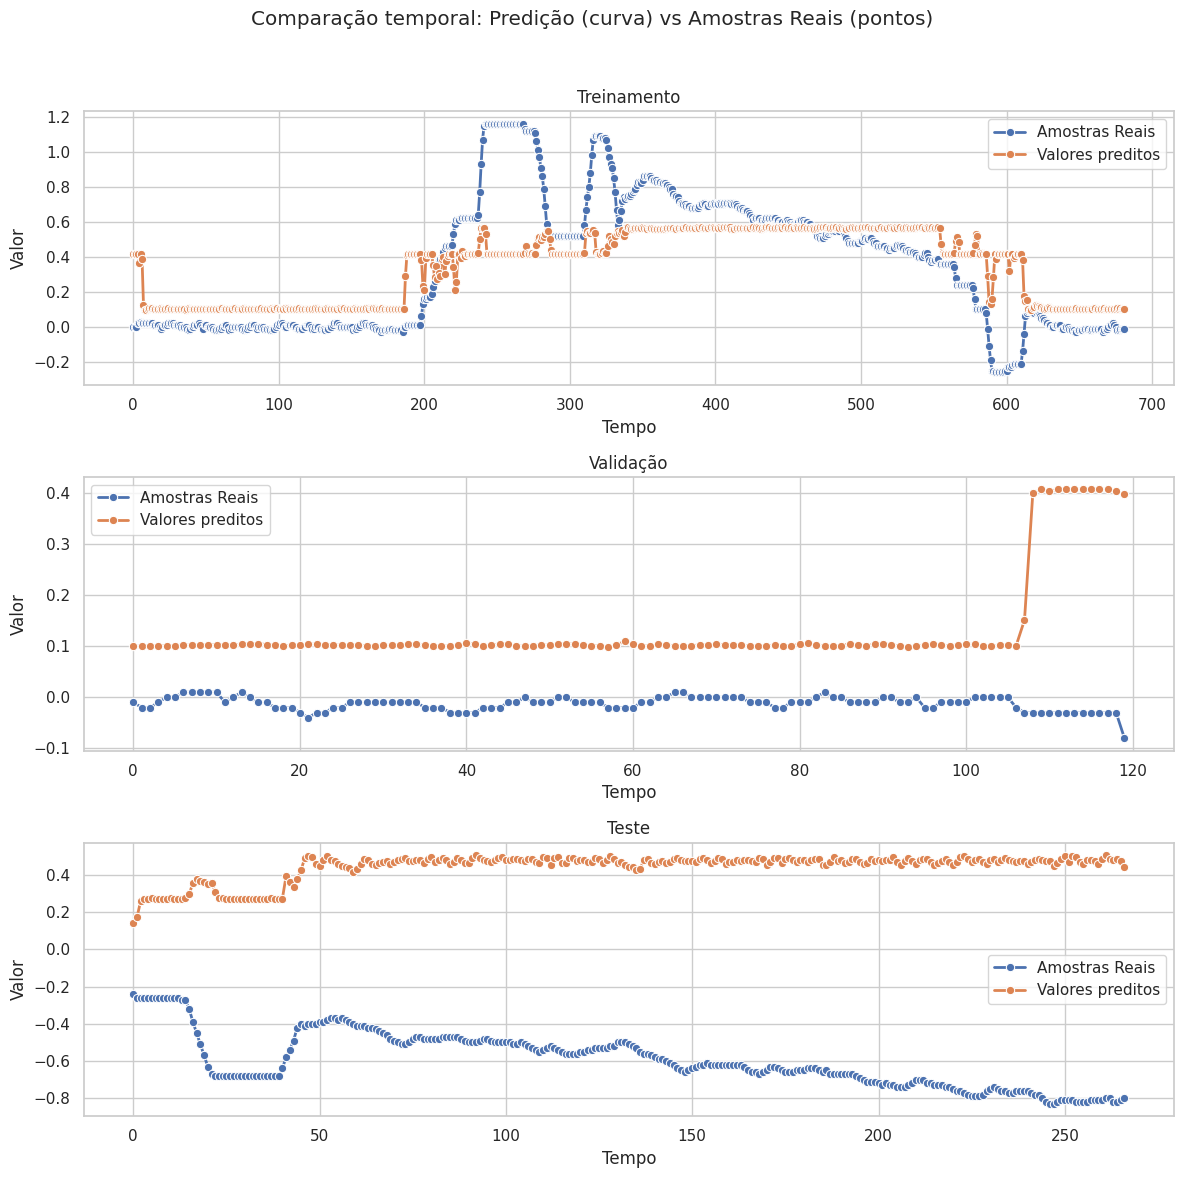

+++++++++++ [4] | 6 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
+++++++++++ [4] | 7 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
+++++++++++ [4] | 8 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
+++++++++++ [4] | 9 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
+++++++++++ [4] | 10 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


,r2_training,mse_training,mape_training,rmse_training,r2_test,mse_test,mape_test,rmse_test,r2_val,mse_val,mape_val,rmse_val
model_2_0,0.500321,0.071132,5.300588e+13,0.266706,-52.660431,1.168988,1.809744,1.081198,-155.658377,0.027910,1.043648e+14,0.167063
model_3_0,0.500656,0.071085,4.582804e+13,0.266617,-60.305983,1.335546,1.954614,1.155658,-130.148863,0.023365,8.980267e+13,0.152858
model_2_1,0.501482,0.070967,5.148733e+13,0.266396,-56.817909,1.259558,1.901051,1.122300,-157.365418,0.028214,1.001495e+14,0.167971
model_3_1,0.501730,0.070932,5.605354e+13,0.266330,-47.188188,1.049776,1.731521,1.024586,-174.101368,0.031196,1.083697e+14,0.176624
model_3_5,0.501739,0.070930,5.043915e+13,0.266328,-48.340688,1.074883,1.741694,1.036766,-150.668751,0.027021,9.777720e+13,0.164381
model_1_0,0.501955,0.070900,5.892956e+13,0.266270,-22.087849,0.502967,1.181356,0.709202,-89.725430,0.016164,1.053030e+14,0.127136
model_1_1,0.502859,0.070771,5.831797e+13,0.266028,-22.195710,0.505317,1.184447,0.710856,-88.433618,0.015933,1.050311e+14,0.126228
model_3_2,0.502901,0.070765,5.138090e+13,0.266017,-49.962896,1.110223,1.778596,1.053671,-155.501955,0.027882,9.944191e+13,0.166980
model_1_2,0.502987,0.070753,5.776660e+13,0.265994,-22.143558,0.504181,1.182956,0.710057,-86.262864,0.015547,1.036435e+14,0.124687
model_4_0,0.503415,0.070692,5.394451e+13,0.265879,-50.151648,1.114334,1.790122,1.055620,-171.949739,0.030813,1.035676e+14,0.175535


DataFrame salvo em ./content/results/metrics_4
Testando combinacao5: Hidden Size=[50], regularizer=0.2, learning_rate=0.01
Shape X (batch, time_steps, features): (682, 2, 2)
Shape Y (batch, output_dim): (682, 1)
Shape h0 (batch, units): (682, 50)
Shape X (batch, time_steps, features): (120, 2, 2)
Shape Y (batch, output_dim): (120, 1)
Shape h0 (batch, units): (120, 50)
Shape X (batch, time_steps, features): (267, 2, 2)
Shape Y (batch, output_dim): (267, 1)
Shape h0 (batch, units): (267, 50)
+++++++++++ [5] | 1 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
+++++++++++ [5] | 2 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
+++++++++++ [5] | 3 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
+++++++++++ [5] | 4 ++++++++++++++++++
22/2

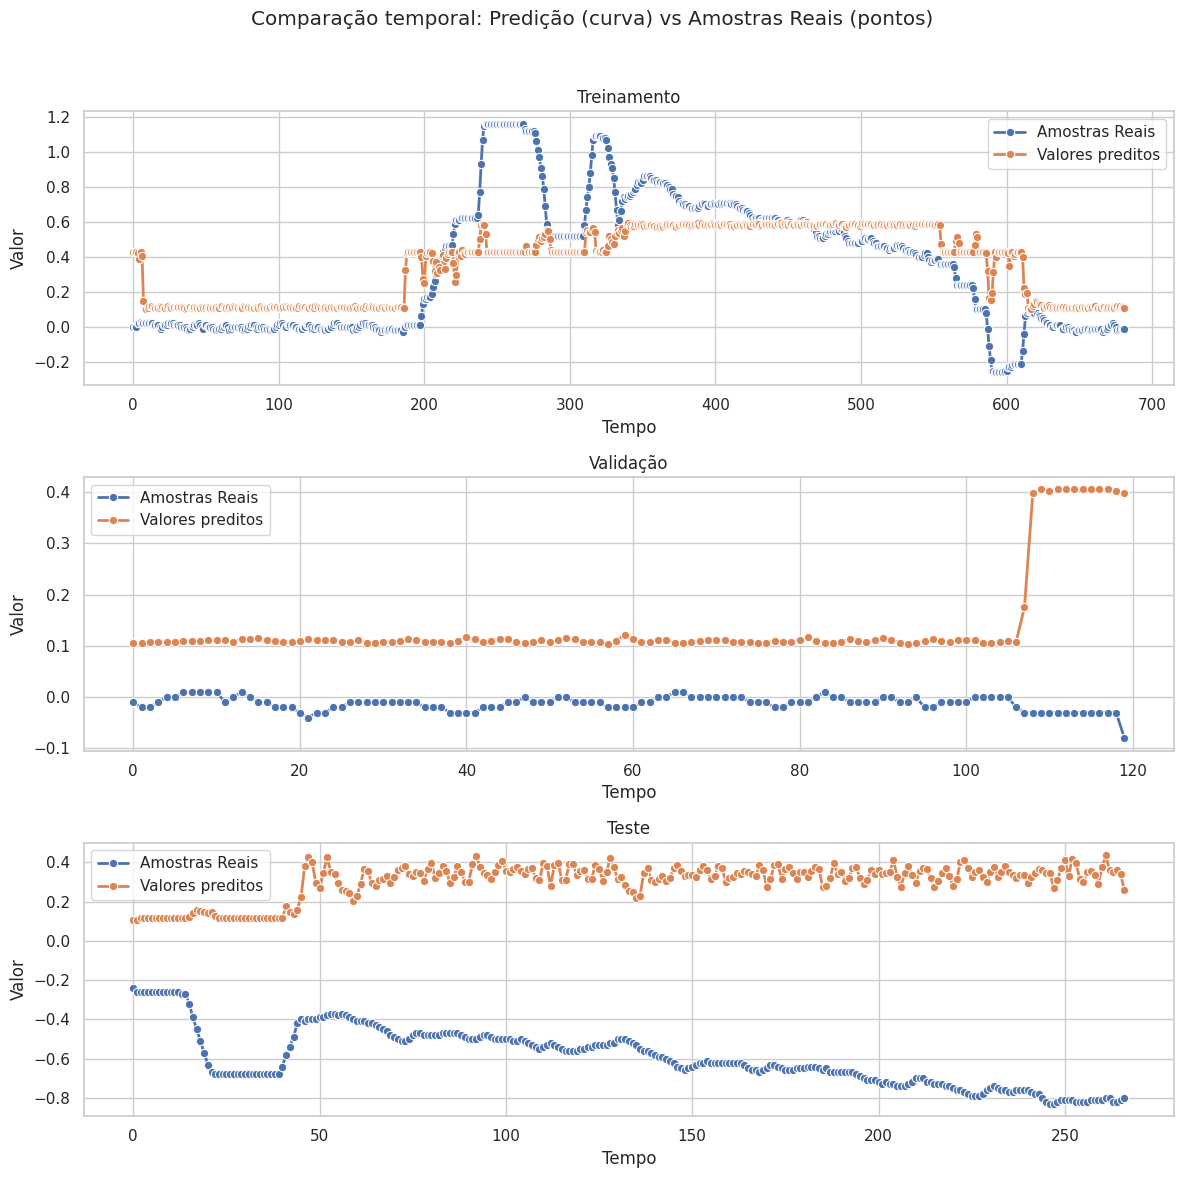

+++++++++++ [5] | 9 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
+++++++++++ [5] | 10 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


,r2_training,mse_training,mape_training,rmse_training,r2_test,mse_test,mape_test,rmse_test,r2_val,mse_val,mape_val,rmse_val
model_2_0,0.500321,0.071132,5.300588e+13,0.266706,-52.660431,1.168988,1.809744,1.081198,-155.658377,0.027910,1.043648e+14,0.167063
model_3_0,0.500656,0.071085,4.582804e+13,0.266617,-60.305983,1.335546,1.954614,1.155658,-130.148863,0.023365,8.980267e+13,0.152858
model_5_0,0.501243,0.071001,5.800667e+13,0.266460,-37.747016,0.844101,1.530110,0.918749,-180.015794,0.032250,1.109262e+14,0.179582
model_2_1,0.501482,0.070967,5.148733e+13,0.266396,-56.817909,1.259558,1.901051,1.122300,-157.365418,0.028214,1.001495e+14,0.167971
model_3_1,0.501730,0.070932,5.605354e+13,0.266330,-47.188188,1.049776,1.731521,1.024586,-174.101368,0.031196,1.083697e+14,0.176624
model_3_5,0.501739,0.070930,5.043915e+13,0.266328,-48.340688,1.074883,1.741694,1.036766,-150.668751,0.027021,9.777720e+13,0.164381
model_1_0,0.501955,0.070900,5.892956e+13,0.266270,-22.087849,0.502967,1.181356,0.709202,-89.725430,0.016164,1.053030e+14,0.127136
model_1_1,0.502859,0.070771,5.831797e+13,0.266028,-22.195710,0.505317,1.184447,0.710856,-88.433618,0.015933,1.050311e+14,0.126228
model_3_2,0.502901,0.070765,5.138090e+13,0.266017,-49.962896,1.110223,1.778596,1.053671,-155.501955,0.027882,9.944191e+13,0.166980
model_1_2,0.502987,0.070753,5.776660e+13,0.265994,-22.143558,0.504181,1.182956,0.710057,-86.262864,0.015547,1.036435e+14,0.124687


DataFrame salvo em ./content/results/metrics_5


In [9]:
Valuer.Evaluate(hidden_sizes = [[30], [35], [40], [45], [50]],
            regularizers=[0.2],
            learning_rate=[0.01],
            run_times = 10, 
            boundarie = 0.5,
            sort_by = 'r2_training',
) 